<a href="https://colab.research.google.com/github/tatyanalitvin/python_for_ds_tasks/blob/dev/Unit_02/HW_2_3/HW_2_3_%D0%94%D0%B5%D1%80%D0%B5%D0%B2%D0%B0_%D0%BF%D1%80%D0%B8%D0%B9%D0%BD%D1%8F%D1%82%D1%82%D1%8F_%D1%80%D1%96%D1%88%D0%B5%D0%BD%D1%8C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Libraries, dependencies, and settings

In [6]:
!pip install dtreeviz

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
import pandas as pd
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 150)

# Training
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree, export_text
from imblearn.over_sampling import SMOTE

from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import f1_score

# Charts
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['font.size'] = 14
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.facecolor'] = '#00000000'

import seaborn as sns
sns.set_style('darkgrid')


# Kaggle setup

In [9]:
import os
from google.colab import userdata
os.environ["KAGGLE_USERNAME"] = userdata.get("KAGGLE_USERNAME")
os.environ["KAGGLE_API_TOKEN"] = userdata.get("KAGGLE_API_TOKEN")

In [10]:
# in case of error, rerun the cell, sometimes creds from the previoues cell take more time to load
from kaggle.api.kaggle_api_extended import KaggleApi

api = KaggleApi()
api.set_config_value("username", userdata.get("KAGGLE_USERNAME"), quiet=True)
api.set_config_value("key", userdata.get("KAGGLE_API_TOKEN"), quiet=True)

In [11]:
def load_competition_data(competition):
    files = api.competition_list_files(competition).files
    for file in files:
        print(file.name)

    return {
        f.name[:-4]: (
            api.competition_download_file(competition, f.name, path='.'),
            pd.read_csv(f.name)
        )[1]
        for f in files if f.name.endswith('.csv')
    }

In [12]:
competition = "bank-customer-churn-prediction-dlu-course-c-4"

dfs = load_competition_data(competition)

raw_train_df = dfs["train"].set_index("id")
raw_test_df = dfs["test"].set_index("id")
raw_sample_submission = dfs["sample_submission"]

sample_submission.csv
test.csv
train.csv


100%|██████████| 97.7k/97.7k [00:00<00:00, 338MB/s]

100%|██████████| 783k/783k [00:00<00:00, 1.08GB/s]

100%|██████████| 1.19M/1.19M [00:00<00:00, 859MB/s]

# HW

В цьому домашньому завданні ми знову працюємо з даними з нашого змагання ["Bank Customer Churn Prediction (DLU Course)"](https://www.kaggle.com/t/7c080c5d8ec64364a93cf4e8f880b6a0).

Тут ми побудуємо рішення задачі класифікації з використанням Decision Trees і зробимо новий submission на змагання на Kaggle.

В цьому ДЗ ми працюємо без pipelines, бо так буде зручніше для візуалізації і інтерпретації моделі дерева прийняття рішень. Так буває і в робочих проєктах: іноді зручніше використати sklearn.Pipelines, іноді зручніше без них. На етапі пошуку рішення (research) зручніше без пайплайнів, а з пайплайнами - коли ви відлагодили процес обробки даних і хочете поекспериментувати з різними моделями і гіперпараметрами.

## **Завдання 1.**

У попередньому домашньому завданні, `HW 2.7 Логістична регресія з scikit learn.ipynb`, ми писали обробку даних для змагання. Ваше завдання зараз - за прикладом, наведеним в лекції `Майстер-клас з перенесення коду з jupyter notebook у Python модуль`, перенести попередню обробку сирих даних з вашого розв'язку ДЗ 2.7 у файл `process_bank_churn.py` в функцію `preprocess_data(...)`.

Функція `preprocess_data()` має приймати `raw_df` і вертати `X_train`, `train_targets`, `X_val`, `val_targets`, `input_cols`(перелік назв колонок, які Ви використовуєте в X), `scaler`, `encoder`, які ми потім будемо використовувати для тренування дерева прийняття рішень.


### Кроки попередньої обробки:

1. Обираємо колонки для роботи. В цьому завдання для чистоти експериментів рекомендую прибрати колонку `Surname`, так буде простіше інтрепретувати модель. Ви можете її додати вже за самостійних подальших експериментів.
2. Розбиття сирих даних на тренувальні і валідаційні.
3. Обробка категоріальних даних (one hot encoding).
4. Масштабування числових даних (було частиною попередньої обробки в попередніх завданнях). Для дерев нам не обовʼязково масштабувати ознаки, тож в коді можна зробити цю частину опціональною, додавши в `preprocess_data` параметр `scaler_numeric`, який приймає значення `True` або `False`. Це дозволить використовувати код попередньоъ обробки з різними моделями.


### Інструкції:
1. Перенесіть попередню обробку даних у файл `process_bank_churn.py`.
2. Забезпечте модулярну структуру функцій: кожна функція повинна виконувати лише одну дію, наприклад, масштабувати ознаки.
3. Додайте докстрінги до кожної функції.
4. Використовуйте typing для аргументів та значень, що повертаються функціями.
5. Передбачте обробку нових даних. Додайте спеціальну функцію `preprocess_new_data(...)`, яка приймає на вхід нові дані в вигляді pandas DataFrame та використовує вже навчені скейлер та енкодер (передані теж як аргументи фукнціх) для їх обробки. Ця функція буде корисною для обробки нових даних перед передбаченням або оцінкою моделі, коли оброблятимемо `test.csv`.

Можна і рекомендовано виконувати це завдання з ChatGPT (бажано, новіше, ніж 3.5) як було наведено у відео-прикладі, тільки **ваше додаткове завдання - розібратись з кодом, який вам згенерувала мовна модель :)**.

### В результаті цього завдання

1. Завантажте ваш готовий `process_bank_churn.py` файл на GitHub у свій репозиторій.
2. Додайте посилання на файл в репозиторії тут у ноутбуці.
3. Нижче зробіть імпорт функції `preprocess_data` з вашого модуля `process_bank_churn.py`.



In [13]:
import sys
sys.path.append('/content/drive/MyDrive/Colab Notebooks/ML for People/HW_2_3')

from process_bank_churn import preprocess_data, preprocess_new_data

In [14]:
EXCLUDE_COLS = ["CustomerId", "Surname", "Exited"]
TARGET_COL = "Exited"

X_train, train_targets, X_val, val_targets, input_cols, scaler, encoder = preprocess_data(
    raw_df = raw_train_df,
    exclude_cols = EXCLUDE_COLS,
    target_col = TARGET_COL,
    )

In [15]:
# Додала SMOTE, бо не подобалося, що модель значно гірші результати за поліноміальну давала,
# так різниця хоч трохи менша
smote = SMOTE(
    random_state = 42,
    k_neighbors = 5, # не впевнена як визначати скільки сусідів брати для такого датасету, взяла 5 але не знаю чи то багато чи ок
    sampling_strategy = "auto",
    )

X_train, train_targets = smote.fit_resample(X_train, train_targets)


## **Завдання 2.**
1. Натренуйте дерево прийняття рішень з зафіксованим `random_state` і з рештою аргументів за замовченням.
2. Виведіть area under ROC для моделі на тренувальних і тестувальних даних. Нам потрібна ця метрика, бо вона основна в змаганні. Модель ок, чи є пере- або недотренування?
3. Виведіть глибину дерева.
4. Побудуйте дерево до глибини 2 включно. Напишіть, які ознаки бачите, що є найвпливовішими тут?
5. Створіть датафрейм `importance_df` з feature importances, де в першому стовпчику `feature` - назва ознаки з нашого Х, а в другому `importance` - значення, наскільки ця ознака є важливою в побудованій моделі. Виведіть топ 10 найвпливовіших ознак разом з їх скором важливості (можна або у вигляді таблиці, або в вигляді barplot).

In [16]:
model = DecisionTreeClassifier(random_state=42)

In [17]:
%%time
model.fit(X_train, train_targets)

CPU times: user 113 ms, sys: 0 ns, total: 113 ms
Wall time: 115 ms


DecisionTreeClassifier(random_state=42)

In [18]:
train_preds = model.predict(X_train)

pd.value_counts(train_preds)

/tmp/ipython-input-1349152595.py:3: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  pd.value_counts(train_preds)


,count
0.0,9558
1.0,9558


In [19]:
# Probabilities
train_probs = model.predict_proba(X_train)
train_probs

array([[1., 0.],
       [1., 0.],
       [1., 0.],
       ...,
       [0., 1.],
       [0., 1.],
       [0., 1.]])

In [20]:
accuracy_score(train_targets, train_preds)

1.0

In [21]:
# ?model.score

In [22]:
# Return the mean accuracy on the given test data and labels.
model.score(X_val, val_targets)

0.8376666666666667

In [23]:
val_targets.value_counts() / len(val_targets)

,count
Exited,
0.0,0.796667
1.0,0.203333


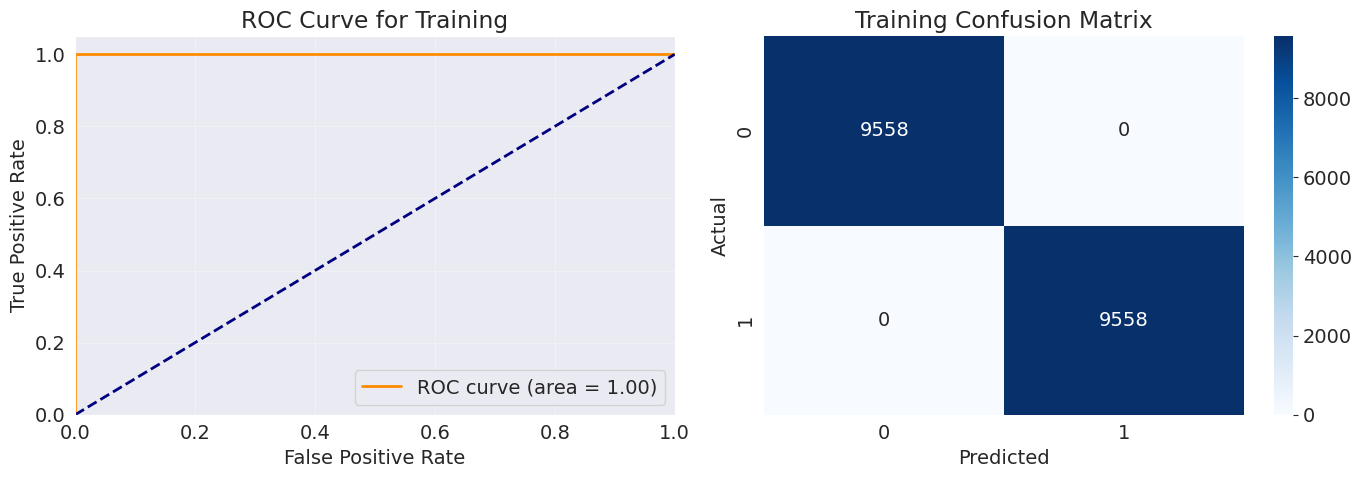

===== Training Results =====
    AUROC: 1.0000
    F1 Score: 1.0000
    




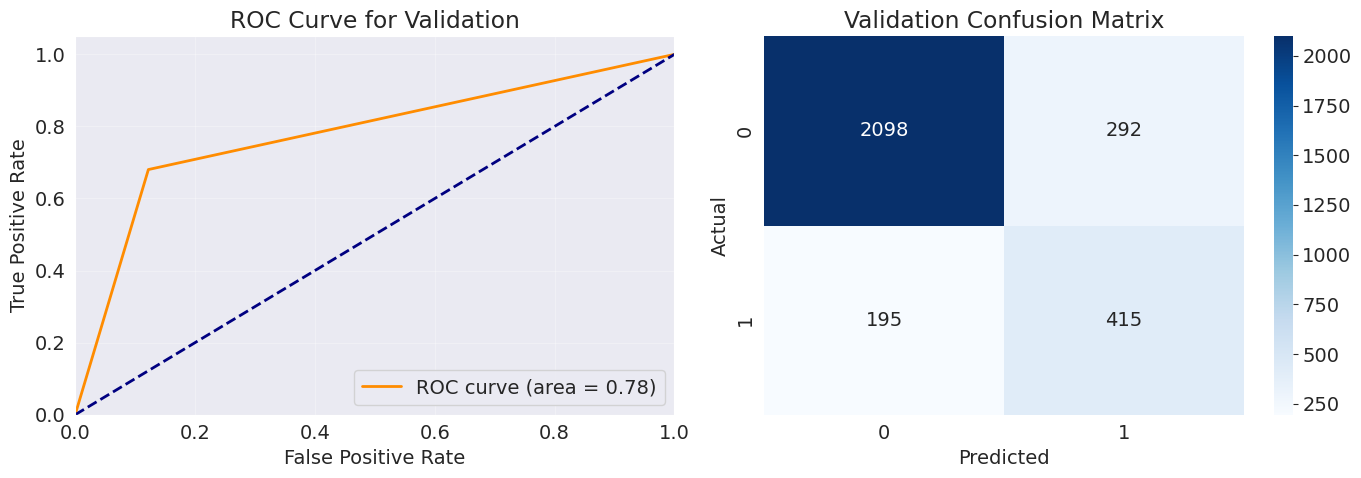

===== Validation Results =====
    AUROC: 0.7791
    F1 Score: 0.6302
    




In [24]:
# 2 - Виведіть area under ROC для моделі на тренувальних і тестувальних даних.
# Нам потрібна ця метрика, бо вона основна в змаганні. Модель ок, чи є пере- або недотренування?

def predict_and_plot(model, inputs, targets, name=""):
    y_pred = model.predict(inputs)
    y_pred_proba = model.predict_proba(inputs)[:, 1]

    # ROC curve
    fpr, tpr, thresholds = roc_curve(targets, y_pred_proba)

    # metrics
    roc_auc = auc(fpr, tpr)
    f1 = f1_score(targets, y_pred)
    cm = confusion_matrix(targets, y_pred)

    # 2 графіки поруч для зручності
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # ROC curve зліва
    axes[0].plot(
        fpr, tpr,
        color="darkorange",
        lw=2,
        label=f"ROC curve (area = {roc_auc:.2f})"
        )
    axes[0].plot(
        [0, 1], [0, 1],
        color="navy",
        lw=2,
        linestyle="--"
        )
    axes[0].set_xlim([0.0, 1.0])
    axes[0].set_ylim([0.0, 1.05])
    axes[0].set_xlabel("False Positive Rate")
    axes[0].set_ylabel("True Positive Rate")
    axes[0].set_title(f"ROC Curve for {name}")
    axes[0].legend(loc="lower right")
    axes[0].grid(True, alpha=0.3)

    # confusion matrix зправа
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=axes[1],
        cbar=True
        )
    axes[1].set_xlabel("Predicted")
    axes[1].set_ylabel("Actual")
    axes[1].set_title(f"{name} Confusion Matrix")

    plt.tight_layout()
    plt.show()

    # Print results
    print(f"""===== {name} Results =====
    AUROC: {roc_auc:.4f}
    F1 Score: {f1:.4f}
    \n\n""")

    return y_pred, roc_auc

train_preds, _ = predict_and_plot(model, X_train, train_targets, "Training")
val_preds, _ = predict_and_plot(model, X_val, val_targets, "Validation")

In [25]:
# 3 - Виведіть глибину дерева.
print(f"Tree Max Depth: {model.tree_.max_depth}")

Tree Max Depth: 23


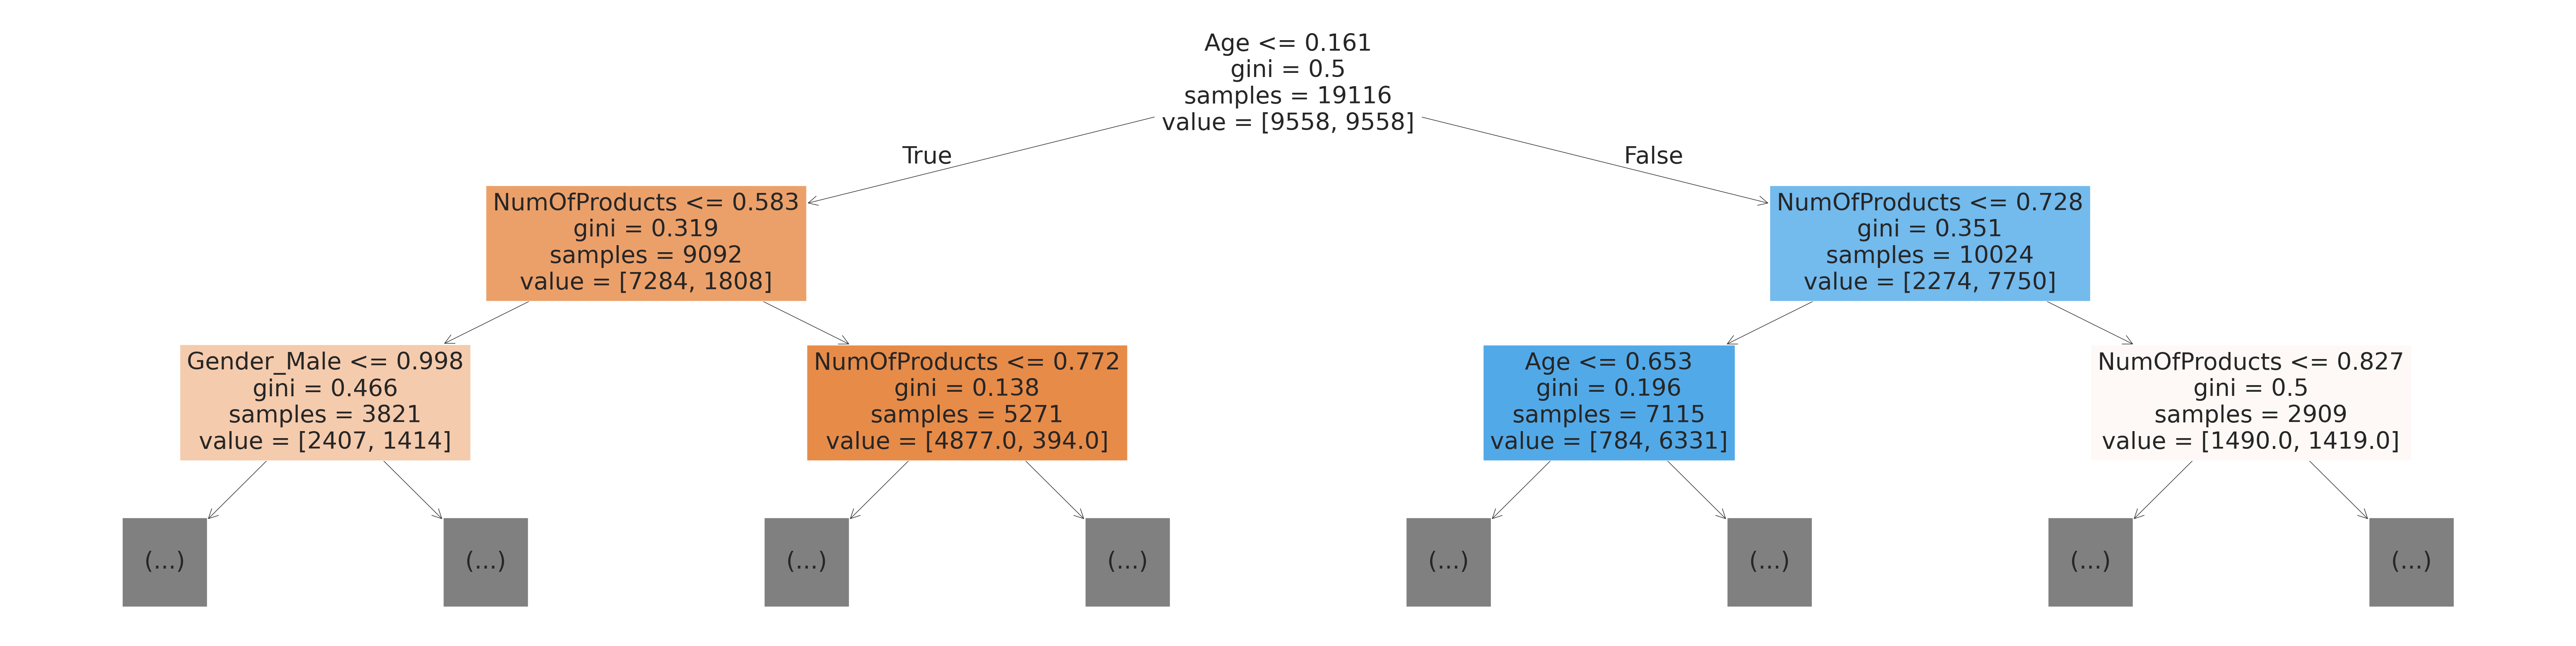

In [26]:
# 4 - Побудуйте дерево до глибини 2 включно.
# Напишіть, які ознаки бачите, що є найвпливовішими тут?
plt.figure(figsize=(80,20))
plot_tree(model, feature_names=X_train.columns, max_depth=2, filled=True);

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names


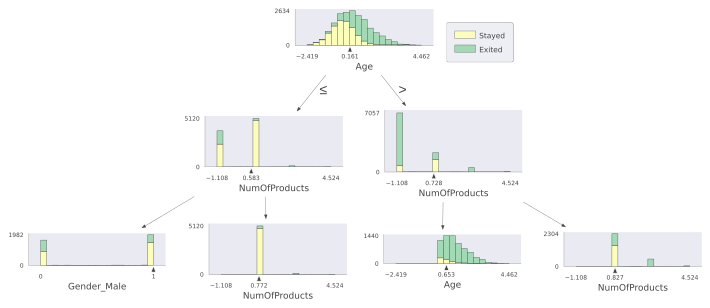

In [27]:
# Нагуглила цікаву бібліотеку для зображення дерев, цікаво, пробую
import logging
import dtreeviz

# Сипало багато warnings з логів, то ж відключаємо і залишаємо лише ERROR
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

viz = dtreeviz.model(
    model,
    X_train=X_train,
    y_train=train_targets,
    feature_names=X_train.columns.tolist(),
    class_names=["Stayed", "Exited"],
)
viz.view(depth_range_to_display=(0, 2))

In [28]:
tree_text = export_text(model, max_depth=2, feature_names=list(X_train.columns))
print(tree_text[:5000])

|--- Age <= 0.16
|   |--- NumOfProducts <= 0.58
|   |   |--- Gender_Male <= 1.00
|   |   |   |--- truncated branch of depth 21
|   |   |--- Gender_Male >  1.00
|   |   |   |--- truncated branch of depth 19
|   |--- NumOfProducts >  0.58
|   |   |--- NumOfProducts <= 0.77
|   |   |   |--- truncated branch of depth 19
|   |   |--- NumOfProducts >  0.77
|   |   |   |--- truncated branch of depth 7
|--- Age >  0.16
|   |--- NumOfProducts <= 0.73
|   |   |--- Age <= 0.65
|   |   |   |--- truncated branch of depth 19
|   |   |--- Age >  0.65
|   |   |   |--- truncated branch of depth 20
|   |--- NumOfProducts >  0.73
|   |   |--- NumOfProducts <= 0.83
|   |   |   |--- truncated branch of depth 19
|   |   |--- NumOfProducts >  0.83
|   |   |   |--- truncated branch of depth 3



Найвпливішими ознаками/фічами (рівень гілок= 2):

* Age - це перше по чому проходить розділ. Менший вік (<= 0.71 після скейлінгу) вказує на більшість Stayed, більший (> 0.71) має більше Exited.
* NumOfProducts - наступний крок розбивки на обох альтернативах попереднього кроку Age.
* На наступноому рівні є повторне використання Age та NumOfProducts, але вже для них інші порогові значення використовуються
Також додається нова фіча IsActiveMember.

In [29]:
# 5 - Створіть датафрейм importance_df з feature importances,
# де в першому стовпчику feature - назва ознаки з нашого Х,
# а в другому importance - значення,
# наскільки ця ознака є важливою в побудованій моделі.
# Виведіть топ 10 найвпливовіших ознак разом з їх скором важливості
# (можна або у вигляді таблиці, або в вигляді barplot).
model.feature_importances_.round(2)

array([0.07, 0.44, 0.05, 0.06, 0.18, 0.01, 0.03, 0.07, 0.  , 0.02, 0.01,
       0.05])

In [30]:
importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

importance_df.style.background_gradient(cmap='YlOrRd', subset=['importance'])

,feature,importance
1,Age,0.443179
4,NumOfProducts,0.178169
7,EstimatedSalary,0.073784
0,CreditScore,0.071311
3,Balance,0.060737
2,Tenure,0.053783
11,Gender_Male,0.051120
6,IsActiveMember,0.028670
9,Geography_Germany,0.020871
10,Geography_Spain,0.007629


/tmp/ipython-input-353866252.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



<Axes: title={'center': 'Feature Importance'}, xlabel='importance', ylabel='feature'>

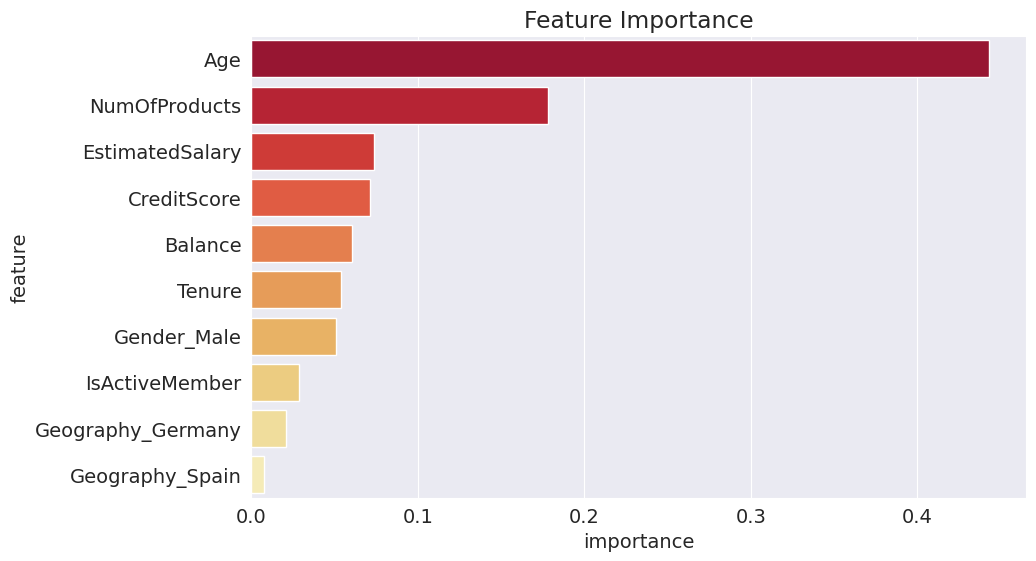

In [31]:
palette = sns.color_palette("YlOrRd_r", n_colors=10)

plt.title('Feature Importance')
sns.barplot(
    data=importance_df.head(10),
    x='importance',
    y='feature',
    palette=palette
    )

## **Завдання 3**.
Спробуйте знайти такі параметри моделі `DecisionTree` аби модель генералізувала ліпше (був вищий показник AUROC на валідаційній вибірці). Проекспериментуйте з різними значеннями параметрів `max_leaf_nodes`, `max_depth` та лишіть ті, які дають найкращий результат, разом з відповідними AUROC на тренувальній і валідаційній вибірках.

В цьому завданні спробуйте просто знайти параметри методом "тика" :)

{'MAX_DEPTH': 3, 'MAX_LEAF_NODES': 8}


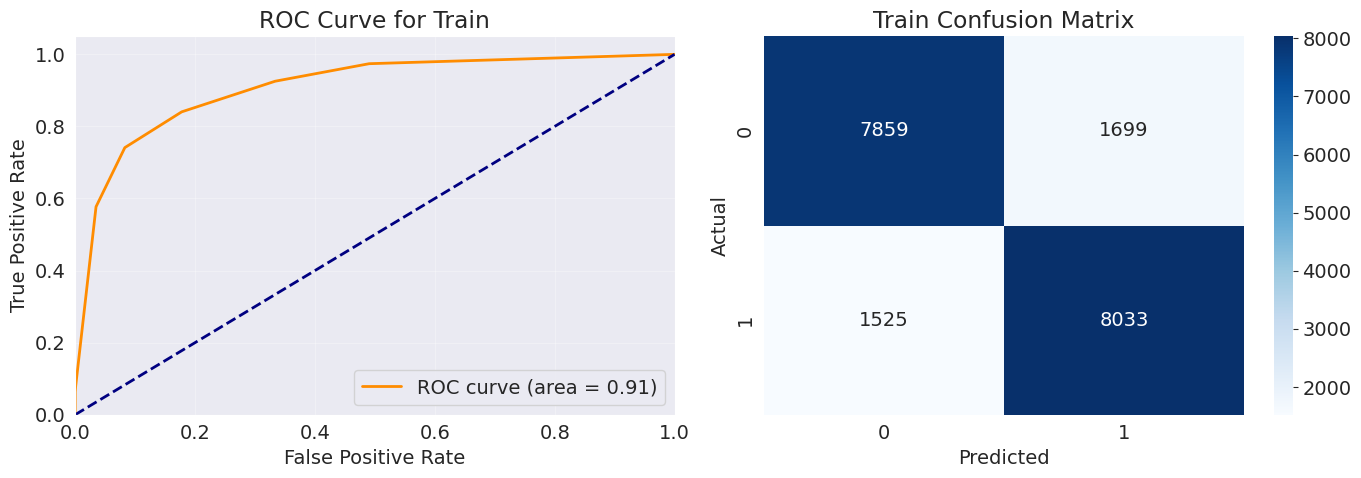

===== Train Results =====
    AUROC: 0.9074
    F1 Score: 0.8329
    




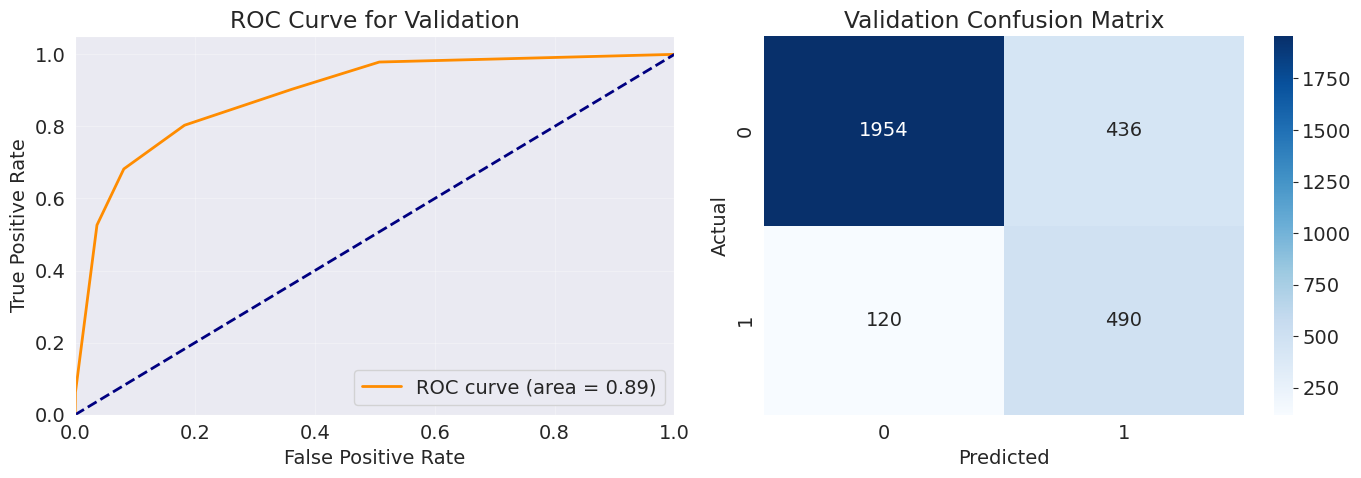

===== Validation Results =====
    AUROC: 0.8902
    F1 Score: 0.6380
    


********************************************************************************************************************************************************************************************************




{'MAX_DEPTH': 4, 'MAX_LEAF_NODES': 16}


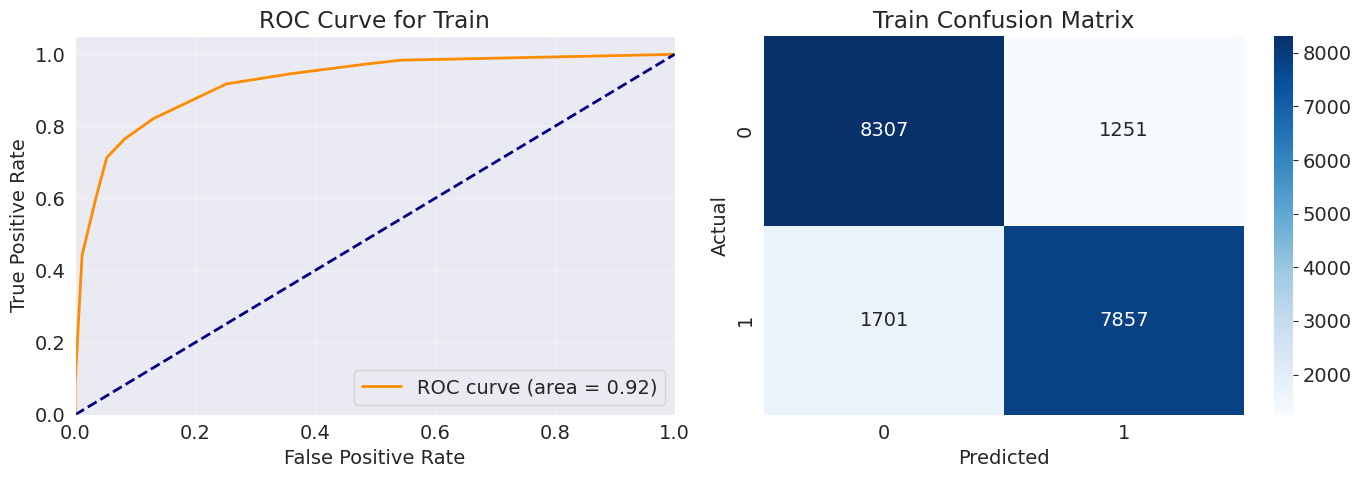

===== Train Results =====
    AUROC: 0.9234
    F1 Score: 0.8419
    




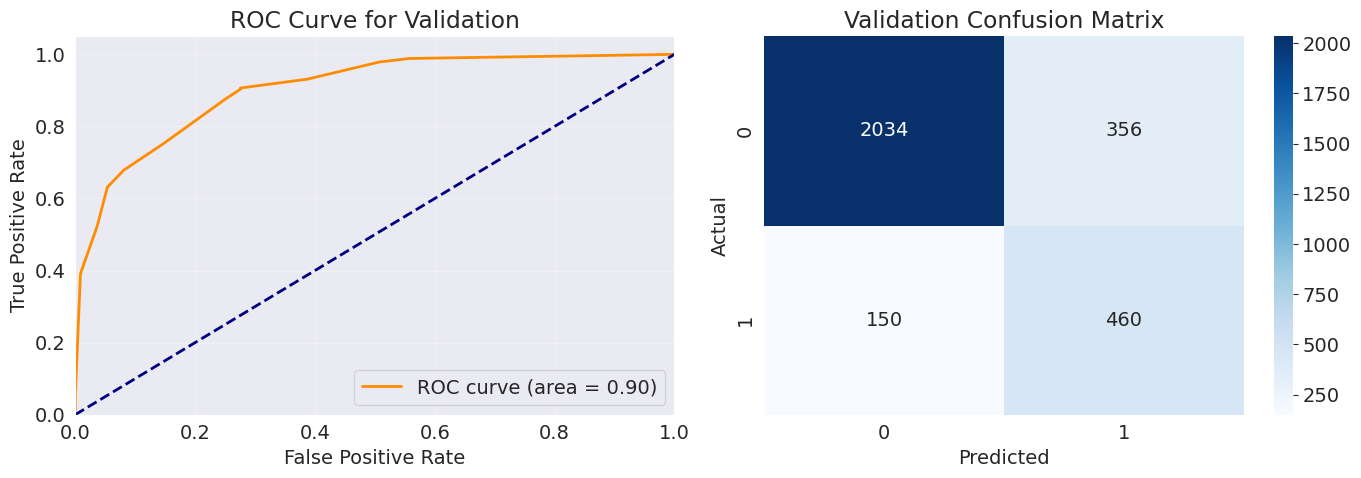

===== Validation Results =====
    AUROC: 0.9026
    F1 Score: 0.6452
    


********************************************************************************************************************************************************************************************************




{'MAX_DEPTH': 5, 'MAX_LEAF_NODES': 32}


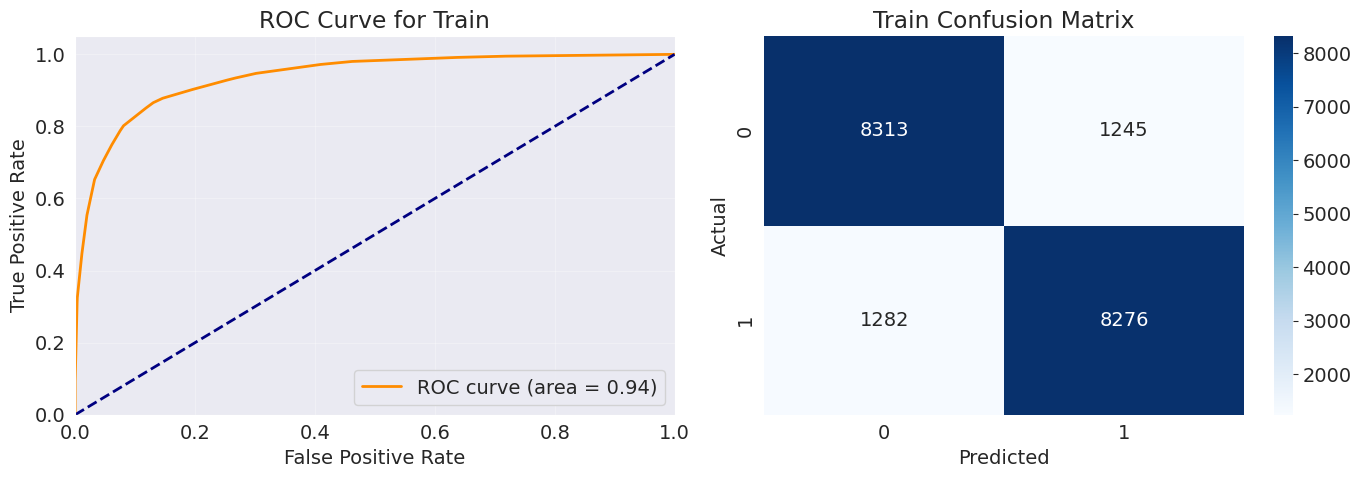

===== Train Results =====
    AUROC: 0.9374
    F1 Score: 0.8676
    




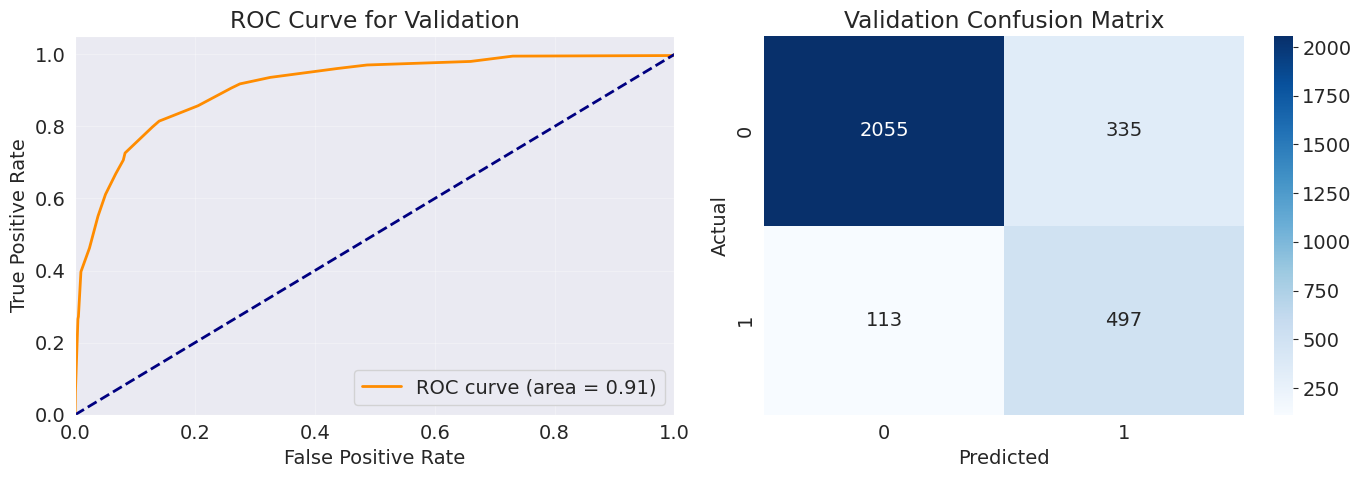

===== Validation Results =====
    AUROC: 0.9125
    F1 Score: 0.6893
    


********************************************************************************************************************************************************************************************************




{'MAX_DEPTH': 6, 'MAX_LEAF_NODES': 64}


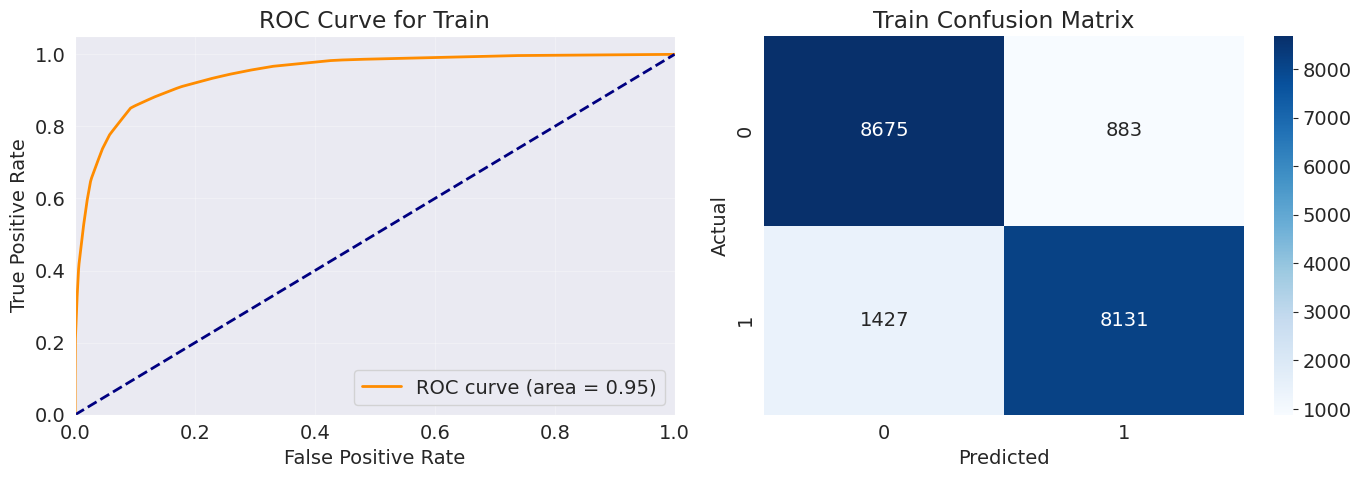

===== Train Results =====
    AUROC: 0.9465
    F1 Score: 0.8756
    




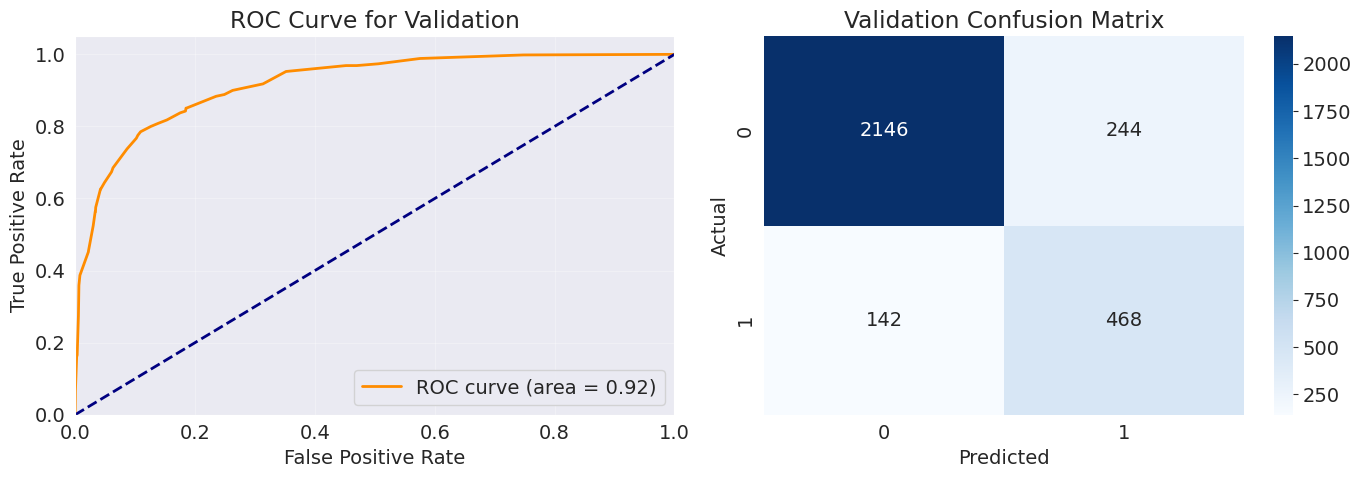

===== Validation Results =====
    AUROC: 0.9180
    F1 Score: 0.7080
    


********************************************************************************************************************************************************************************************************




{'MAX_DEPTH': 10, 'MAX_LEAF_NODES': 32}


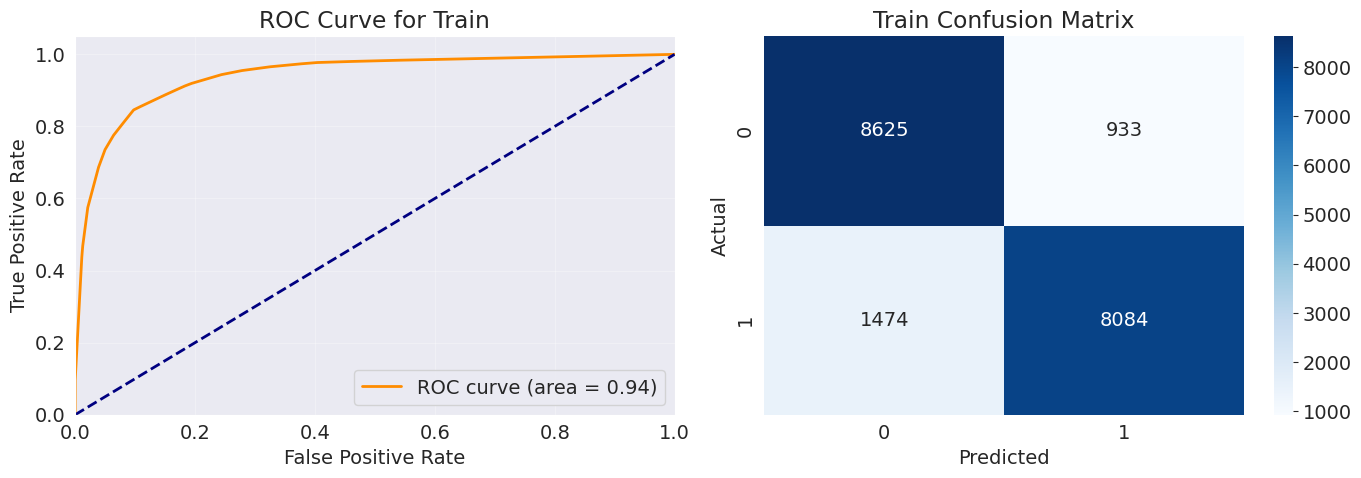

===== Train Results =====
    AUROC: 0.9405
    F1 Score: 0.8704
    




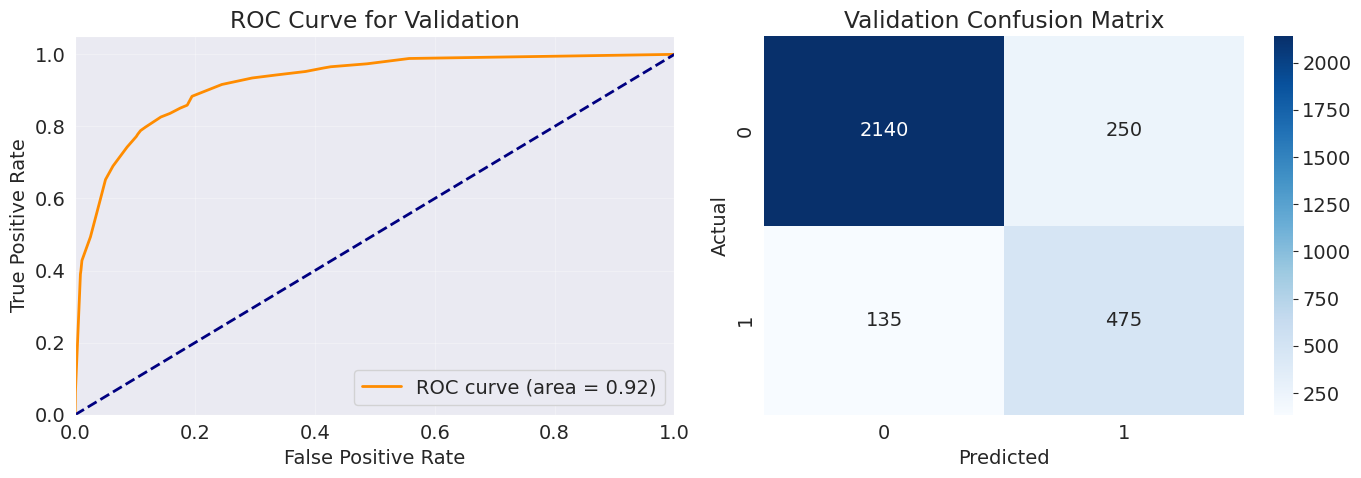

===== Validation Results =====
    AUROC: 0.9215
    F1 Score: 0.7116
    


********************************************************************************************************************************************************************************************************




{'MAX_DEPTH': 6, 'MAX_LEAF_NODES': 32}


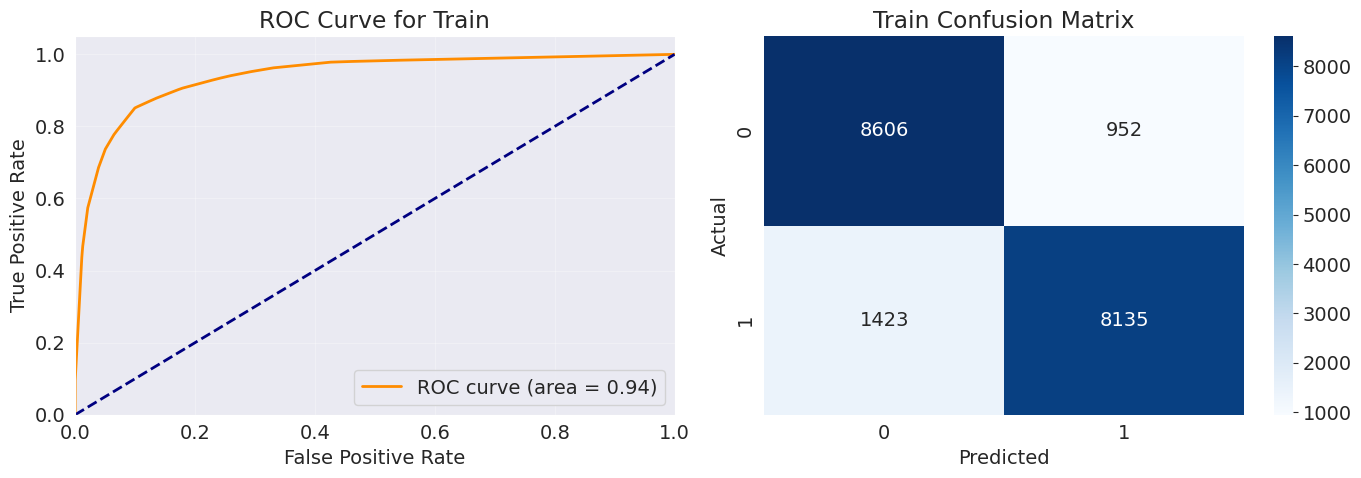

===== Train Results =====
    AUROC: 0.9393
    F1 Score: 0.8726
    




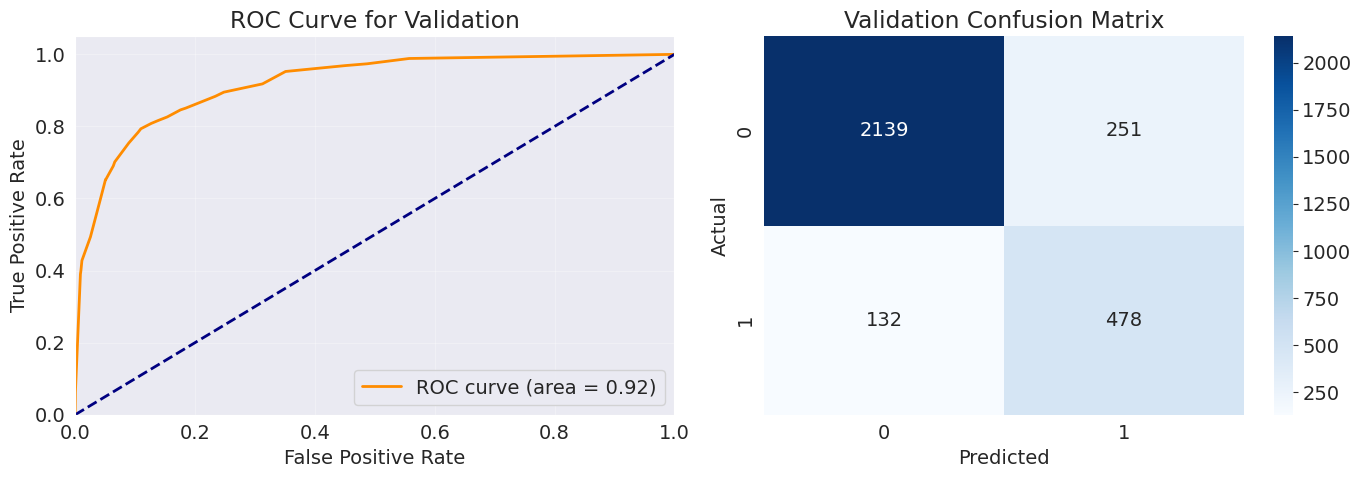

===== Validation Results =====
    AUROC: 0.9185
    F1 Score: 0.7140
    


********************************************************************************************************************************************************************************************************




{'MAX_DEPTH': 7, 'MAX_LEAF_NODES': 41}


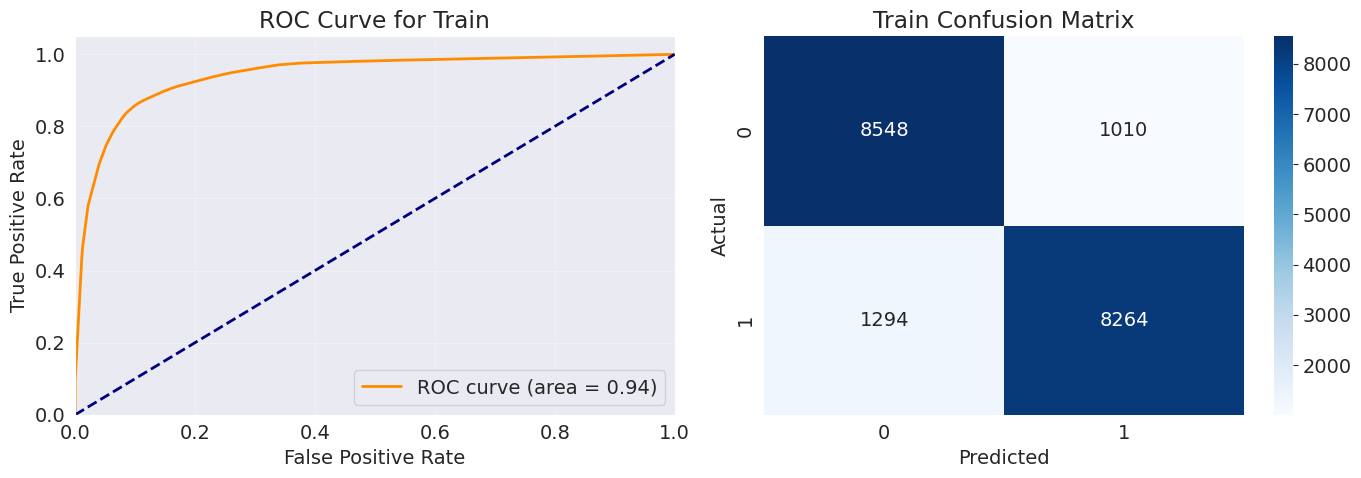

===== Train Results =====
    AUROC: 0.9424
    F1 Score: 0.8777
    




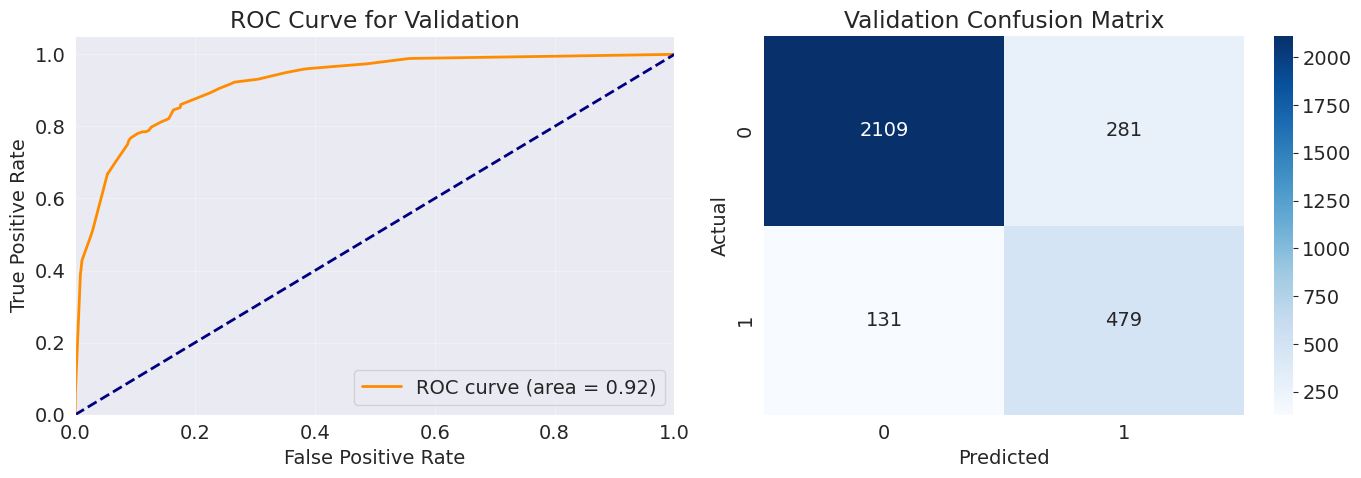

===== Validation Results =====
    AUROC: 0.9207
    F1 Score: 0.6993
    


********************************************************************************************************************************************************************************************************




{'MAX_DEPTH': 8, 'MAX_LEAF_NODES': 39}


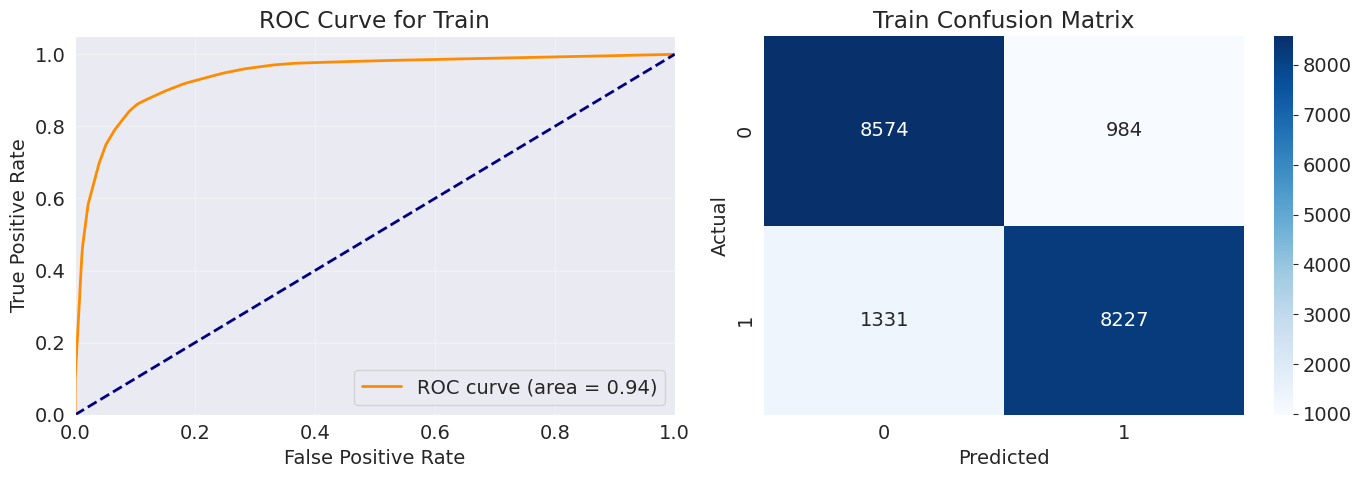

===== Train Results =====
    AUROC: 0.9429
    F1 Score: 0.8767
    




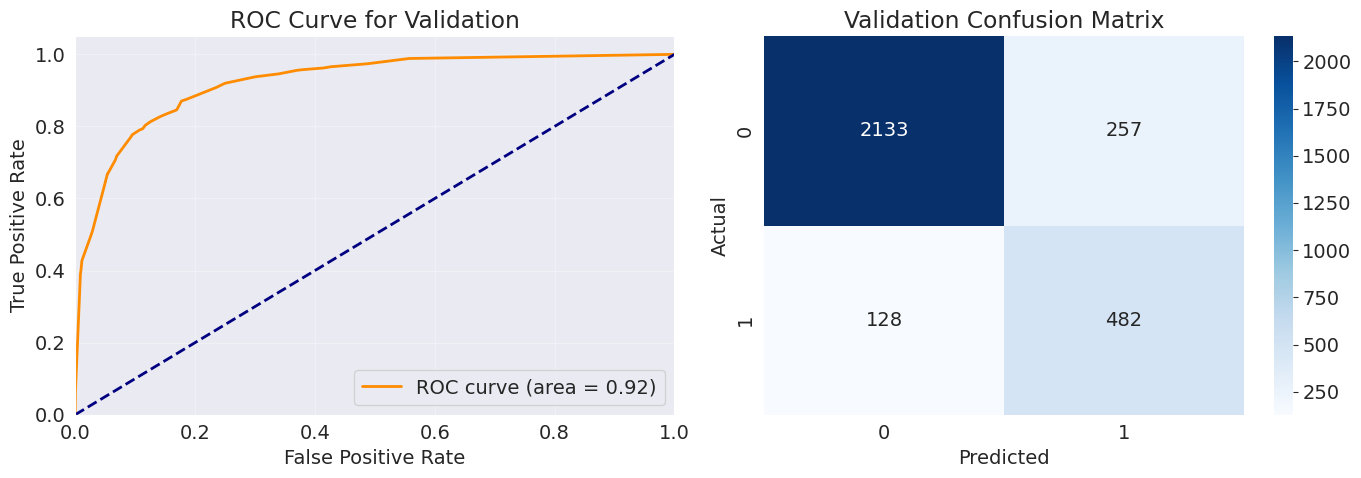

===== Validation Results =====
    AUROC: 0.9228
    F1 Score: 0.7146
    


********************************************************************************************************************************************************************************************************




{'MAX_DEPTH': 18, 'MAX_LEAF_NODES': 100}


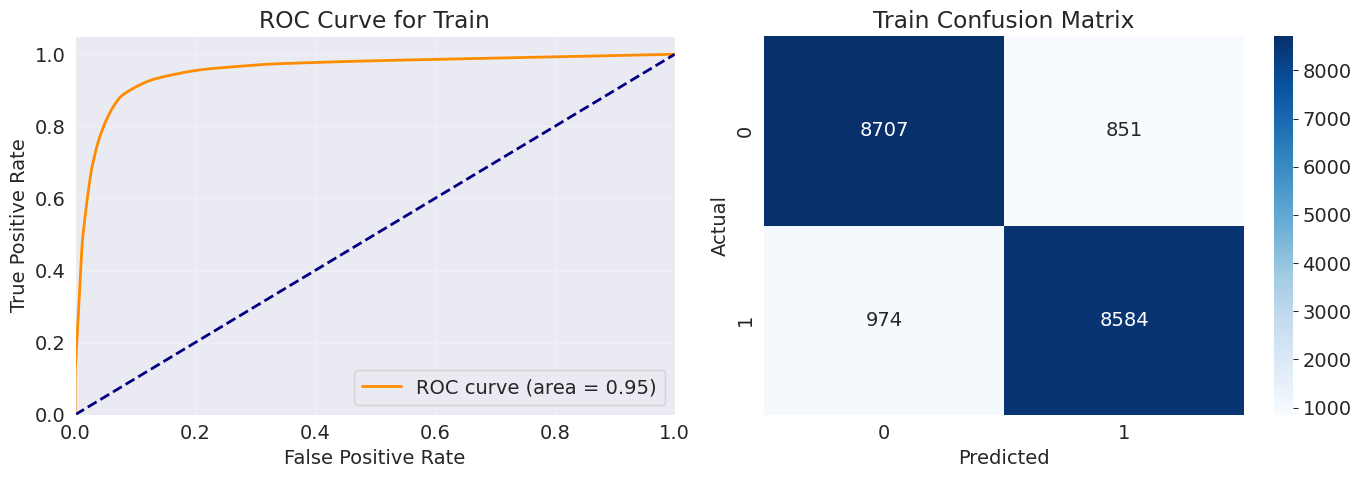

===== Train Results =====
    AUROC: 0.9544
    F1 Score: 0.9039
    




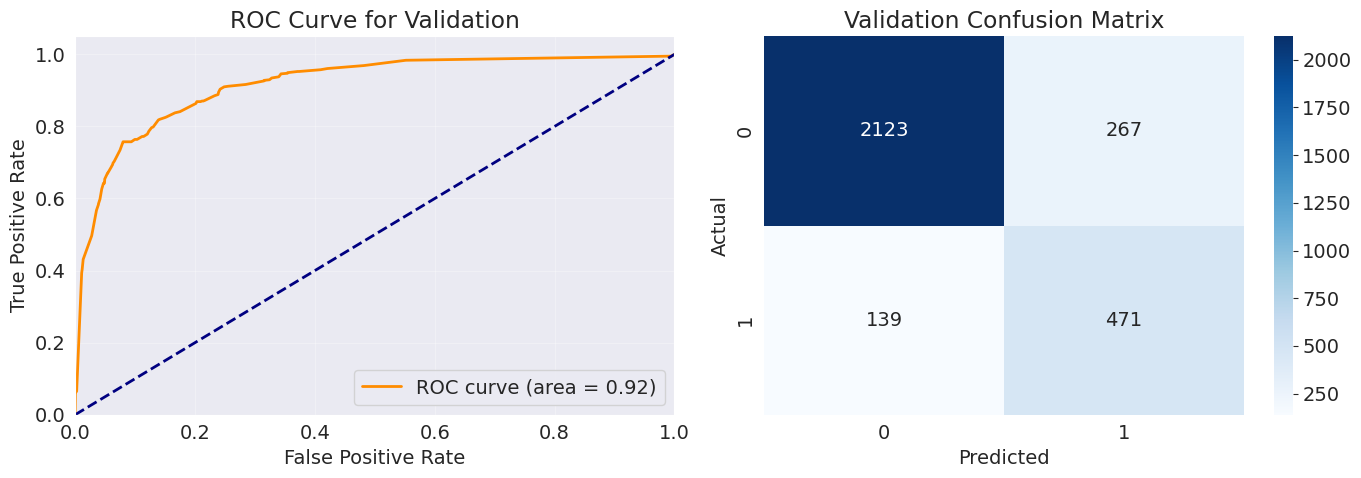

===== Validation Results =====
    AUROC: 0.9155
    F1 Score: 0.6988
    


********************************************************************************************************************************************************************************************************




{'MAX_DEPTH': 18, 'MAX_LEAF_NODES': 50}


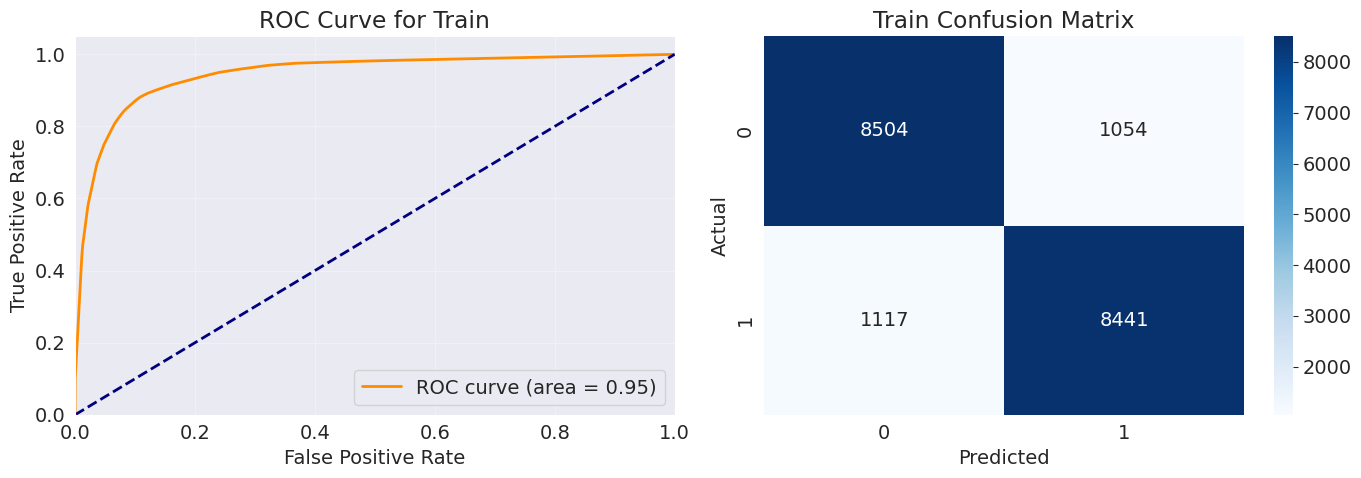

===== Train Results =====
    AUROC: 0.9456
    F1 Score: 0.8861
    




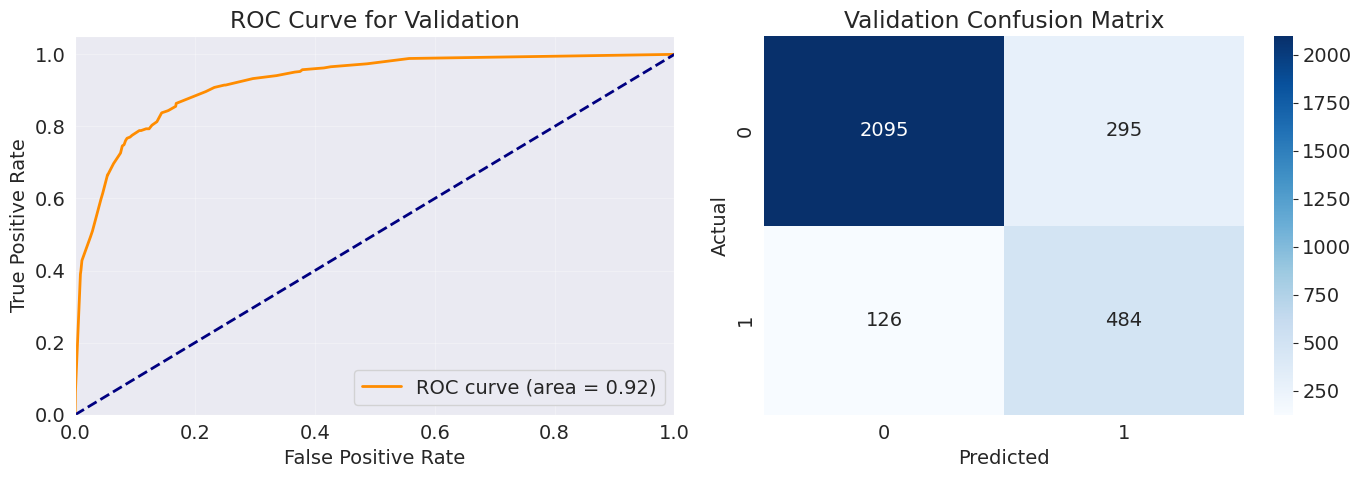

===== Validation Results =====
    AUROC: 0.9223
    F1 Score: 0.6969
    


********************************************************************************************************************************************************************************************************






In [32]:
experiments = [
    {"max_depth": 3,  "max_leaf_nodes": 8},
    {"max_depth": 4,  "max_leaf_nodes": 16},
    {"max_depth": 5,  "max_leaf_nodes": 32},
    {"max_depth": 6,  "max_leaf_nodes": 64},
    {"max_depth": 10, "max_leaf_nodes": 32},
    {"max_depth": 6,  "max_leaf_nodes": 32},
    {"max_depth": 7,  "max_leaf_nodes": 41},
    {"max_depth": 8,  "max_leaf_nodes": 39},
    {"max_depth": 18,  "max_leaf_nodes": 100},
    {"max_depth": 18,  "max_leaf_nodes": 50},
]

def run_experiments(experiments):
    results = []
    for params in experiments:
        m = DecisionTreeClassifier(random_state=42, **params)
        m.fit(X_train, train_targets)

        print(f"{params}".upper())
        _, train_auc = predict_and_plot(m, X_train, train_targets, f"Train")
        _, val_auc = predict_and_plot(m, X_val, val_targets, f"Validation")

        print("****"*50)
        print('\n\n\n')
        results.append({**params, "train_auroc": train_auc, "val_auroc": val_auc})
    return results

experiments_results_set_1 = run_experiments(experiments)

In [33]:
results_set_1_df = pd.DataFrame(experiments_results_set_1).sort_values("val_auroc", ascending=False)
results_set_1_df.style.background_gradient(cmap="YlOrRd", subset=["train_auroc", "val_auroc"])

,max_depth,max_leaf_nodes,train_auroc,val_auroc
7,8,39,0.942876,0.922837
9,18,50,0.945562,0.922279
4,10,32,0.940526,0.921475
6,7,41,0.942434,0.920698
5,6,32,0.939307,0.918519
3,6,64,0.946513,0.917980
8,18,100,0.954441,0.915481
2,5,32,0.937390,0.912511
1,4,16,0.923434,0.902635
0,3,8,0.907407,0.890221


In [34]:
# DO NOT RUN unleas you have >30m to wait
# Brute Force експеримет, бо а чому б і ні :D
# experiments = [
#     {"max_depth": d, "max_leaf_nodes": l} for d in range(1,21) for l in range(2,65)
# ]

# results = run_experiments(experiments)

In [35]:
# results_df = pd.DataFrame(results).sort_values("val_auroc", ascending=False)
# results_df.style.background_gradient(cmap="YlOrRd", subset=["train_auroc", "val_auroc"])

## **Завдання 4**.
В циклі пройдіться по значенням max_depth від 1 до 20 включно, на кожній ітерації натренуйте DecisionTree модель і виміряйте AUROC на трейн і валідаційних даних.

В кінці виведіть на графік залеєність між AUROC на трейн і валідаційних даних і номером ітерації.

{'MAX_DEPTH': 1}


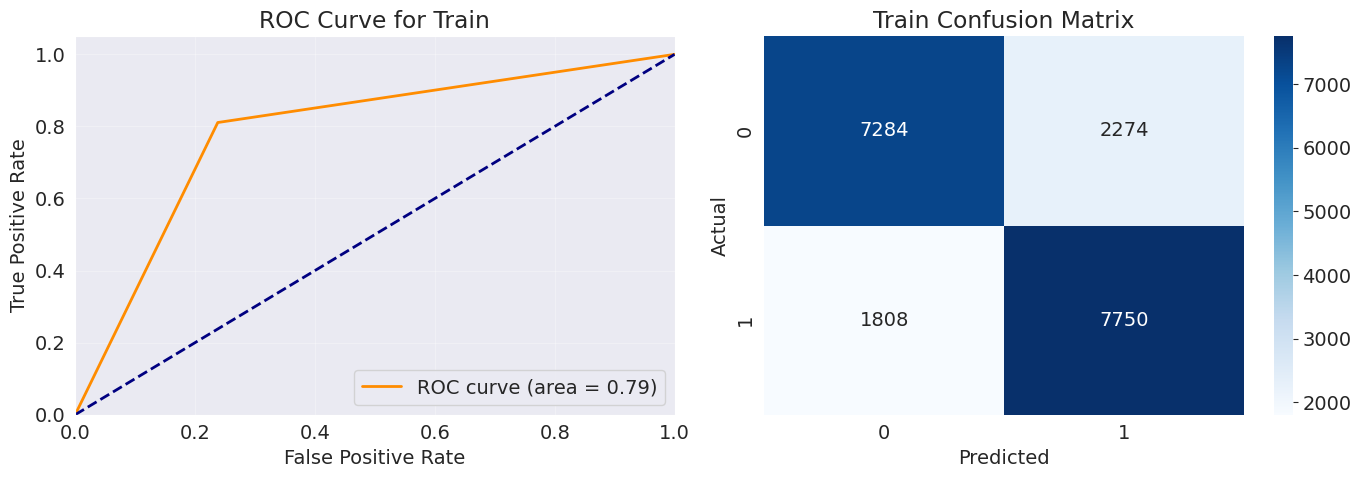

===== Train Results =====
    AUROC: 0.7865
    F1 Score: 0.7915
    




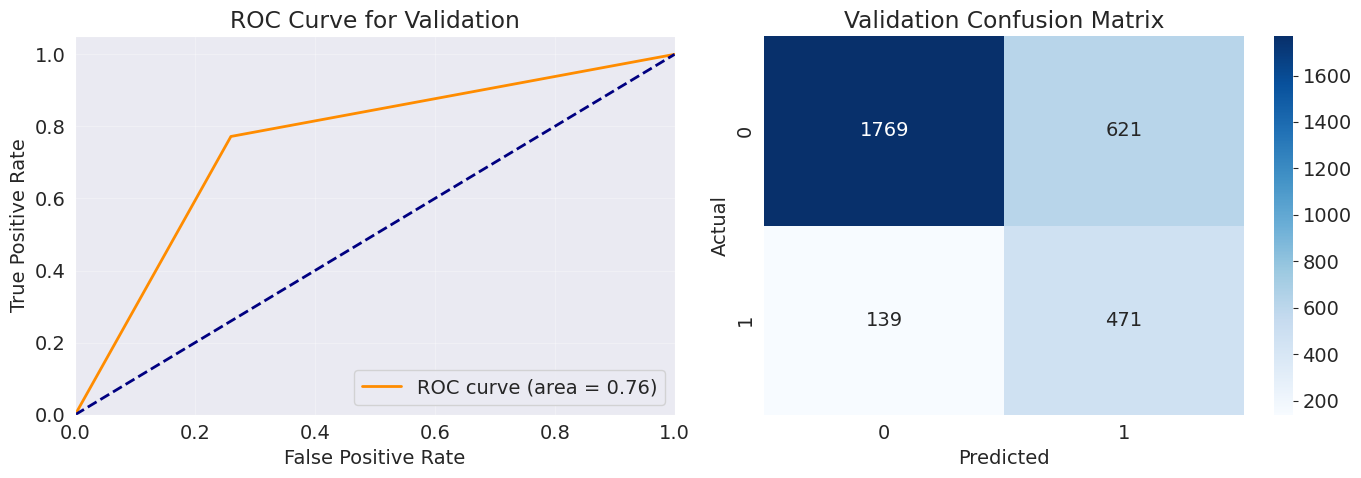

===== Validation Results =====
    AUROC: 0.7561
    F1 Score: 0.5535
    


********************************************************************************************************************************************************************************************************




{'MAX_DEPTH': 2}


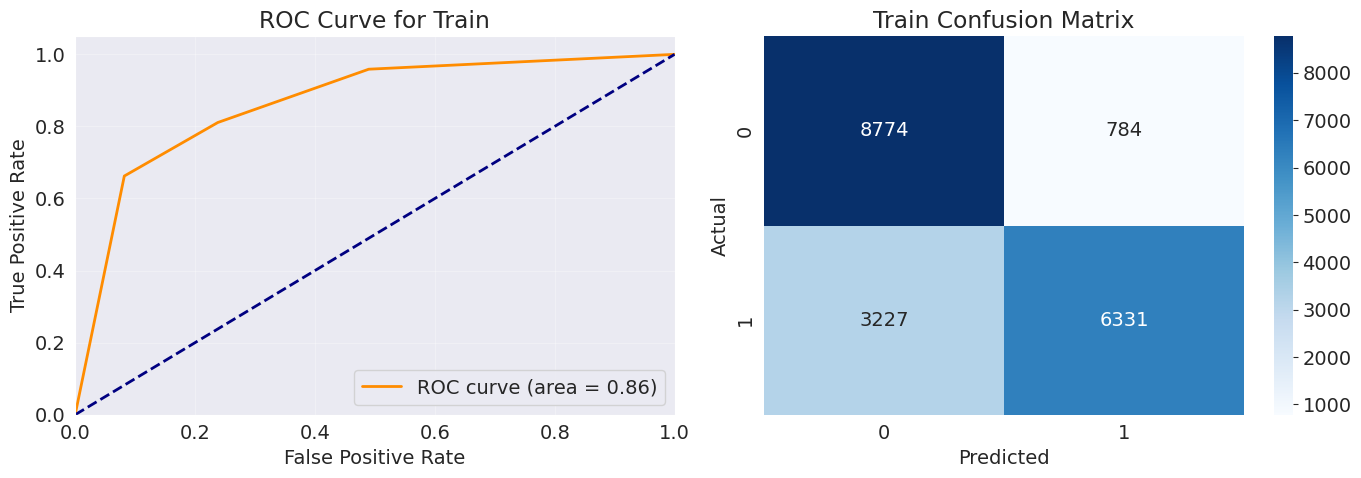

===== Train Results =====
    AUROC: 0.8646
    F1 Score: 0.7594
    




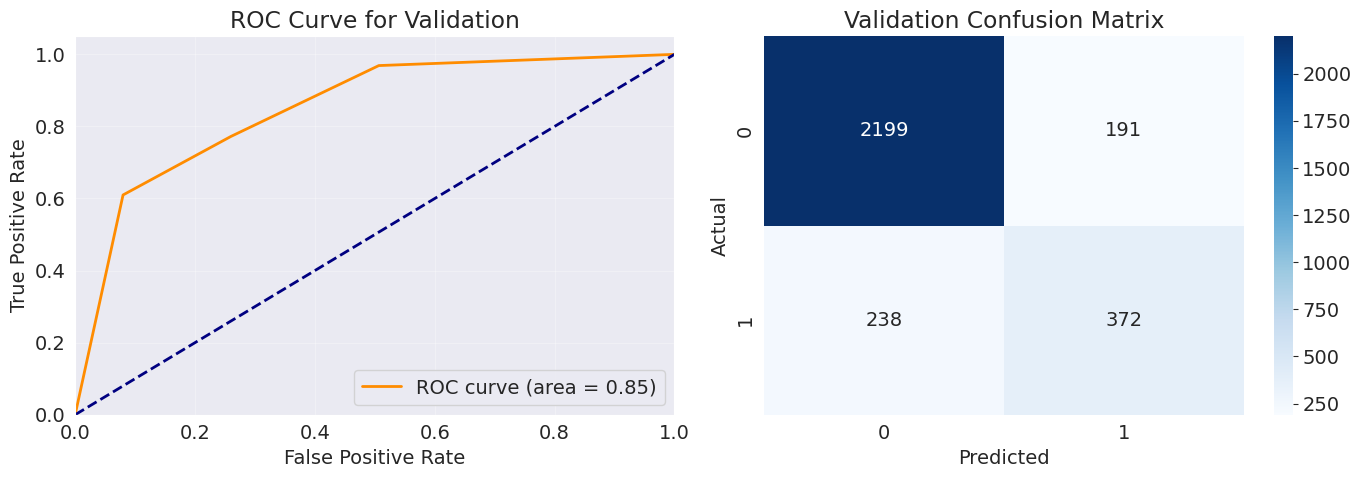

===== Validation Results =====
    AUROC: 0.8492
    F1 Score: 0.6343
    


********************************************************************************************************************************************************************************************************




{'MAX_DEPTH': 3}


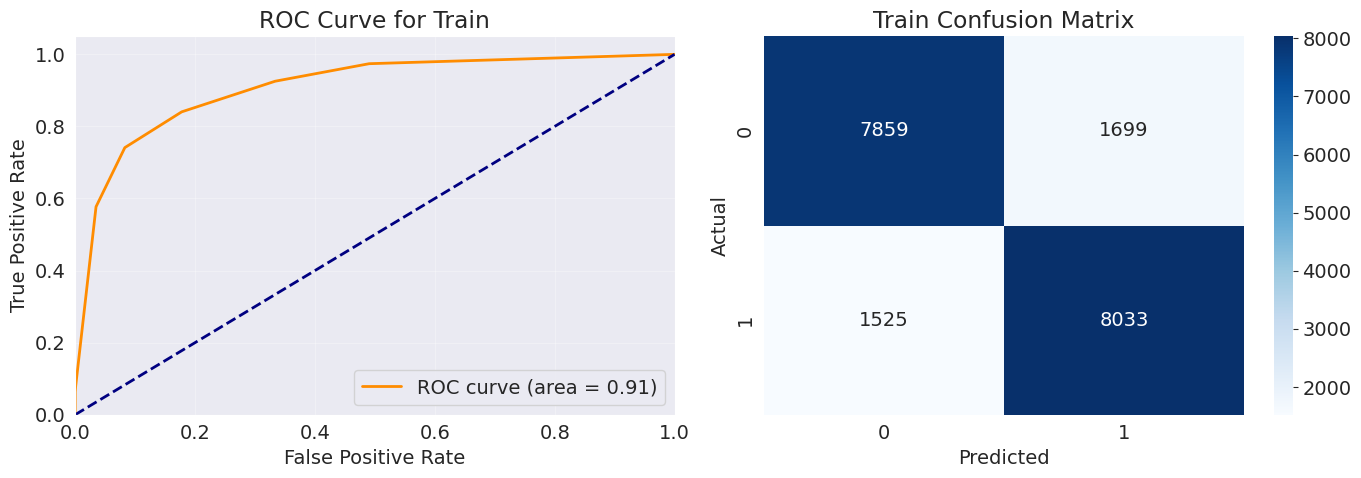

===== Train Results =====
    AUROC: 0.9074
    F1 Score: 0.8329
    




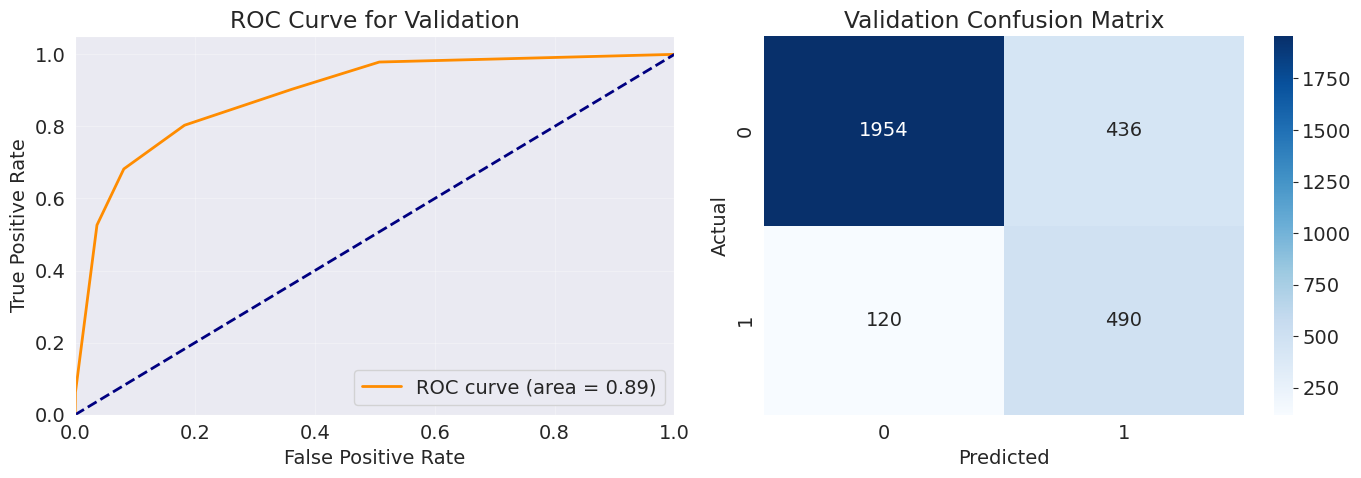

===== Validation Results =====
    AUROC: 0.8902
    F1 Score: 0.6380
    


********************************************************************************************************************************************************************************************************




{'MAX_DEPTH': 4}


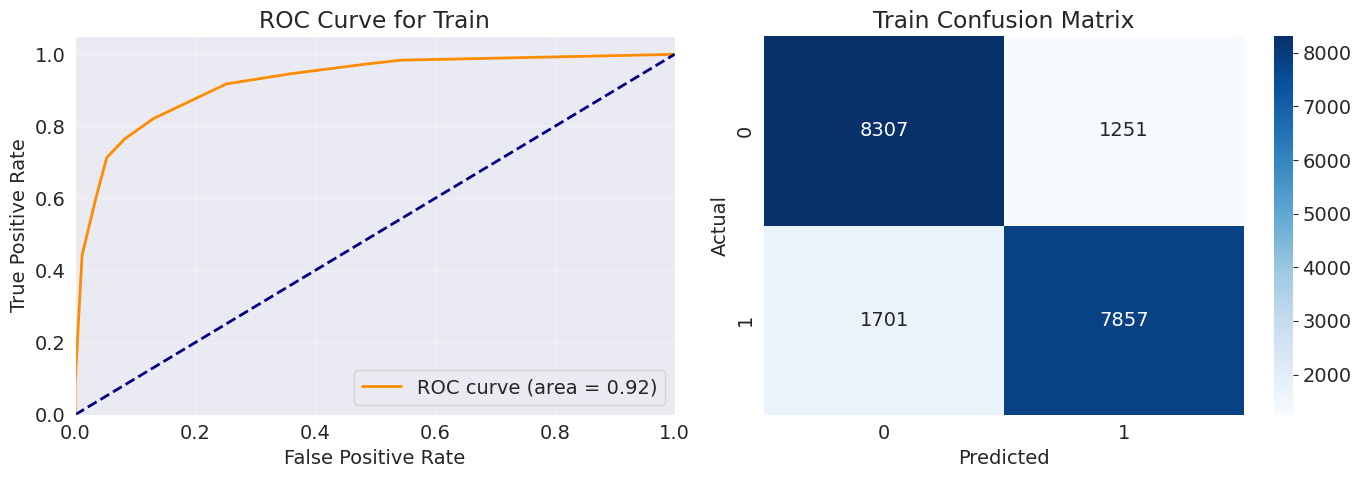

===== Train Results =====
    AUROC: 0.9234
    F1 Score: 0.8419
    




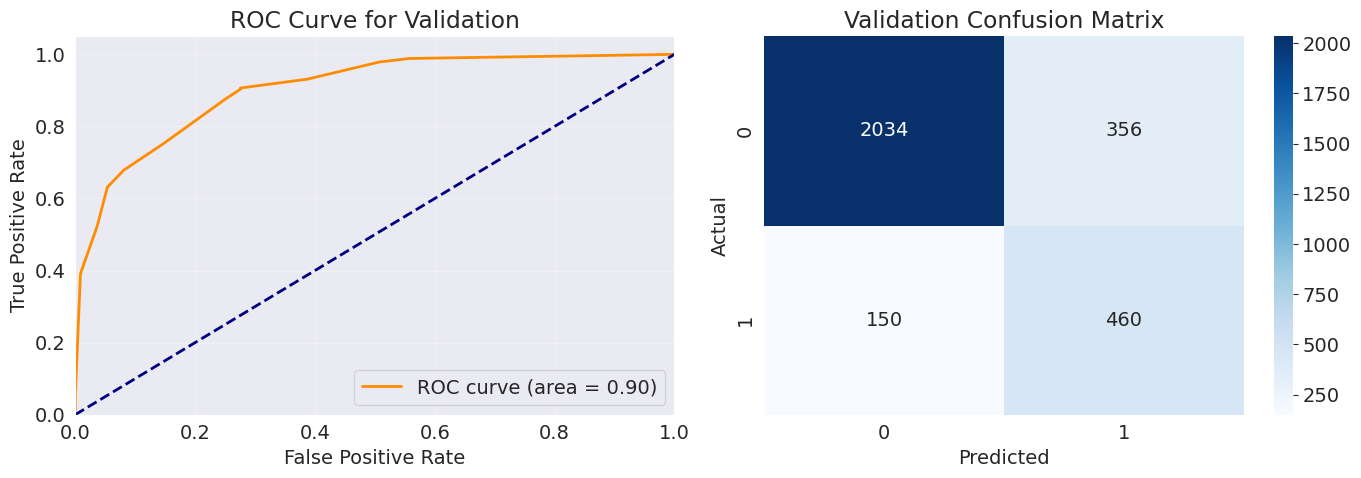

===== Validation Results =====
    AUROC: 0.9026
    F1 Score: 0.6452
    


********************************************************************************************************************************************************************************************************




{'MAX_DEPTH': 5}


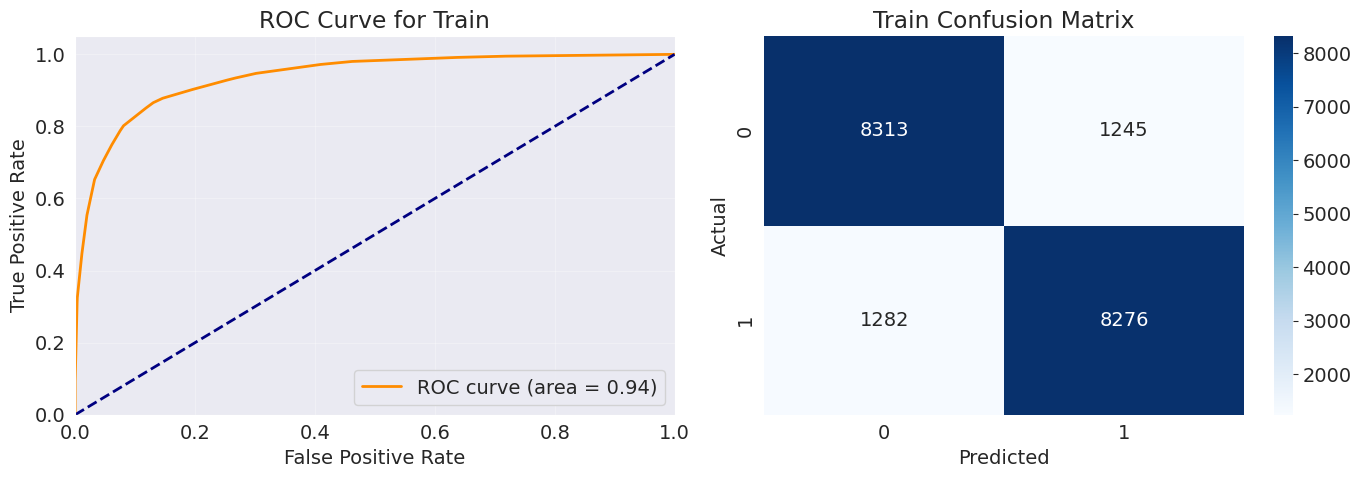

===== Train Results =====
    AUROC: 0.9374
    F1 Score: 0.8676
    




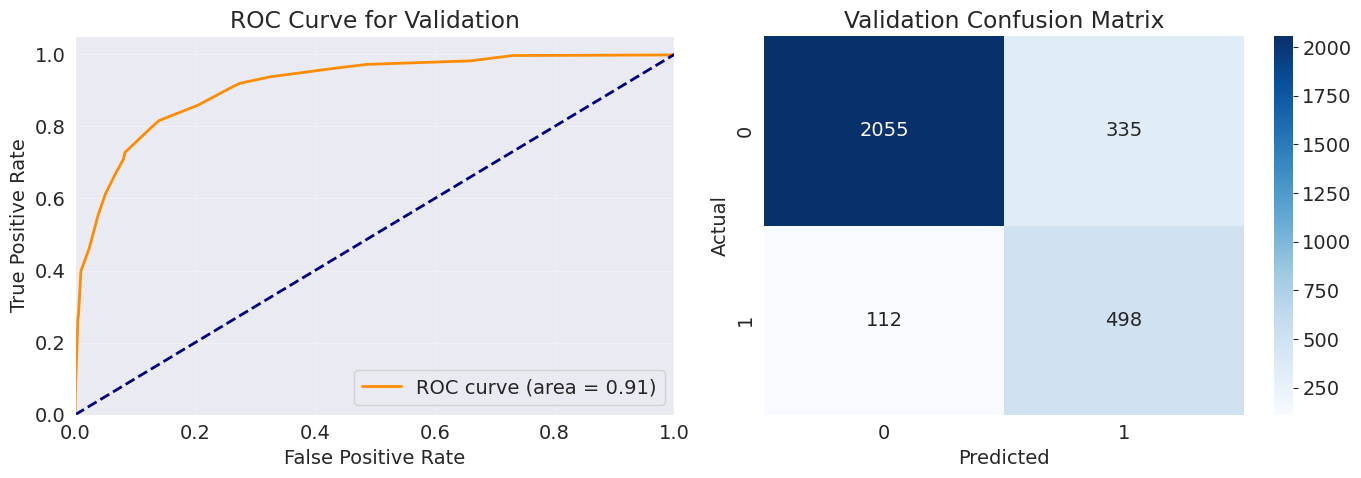

===== Validation Results =====
    AUROC: 0.9142
    F1 Score: 0.6902
    


********************************************************************************************************************************************************************************************************




{'MAX_DEPTH': 6}


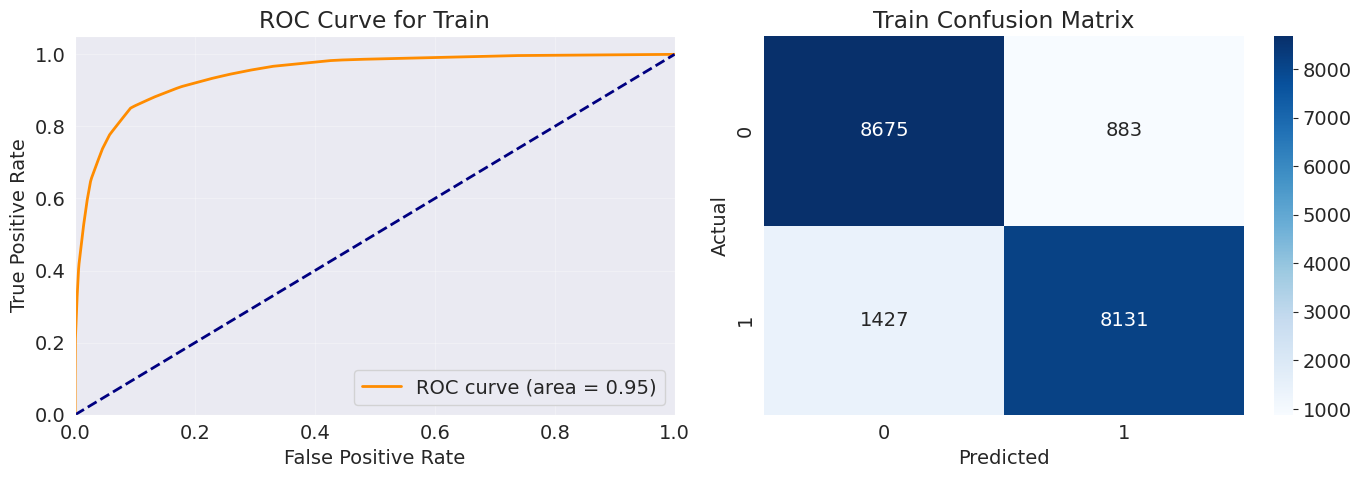

===== Train Results =====
    AUROC: 0.9465
    F1 Score: 0.8756
    




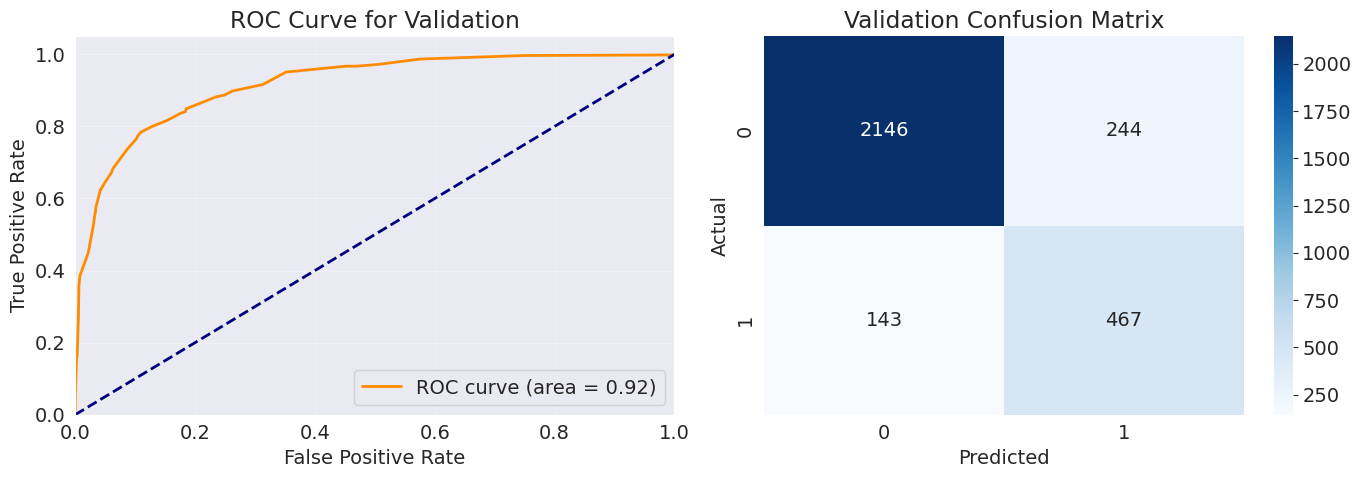

===== Validation Results =====
    AUROC: 0.9163
    F1 Score: 0.7070
    


********************************************************************************************************************************************************************************************************




{'MAX_DEPTH': 7}


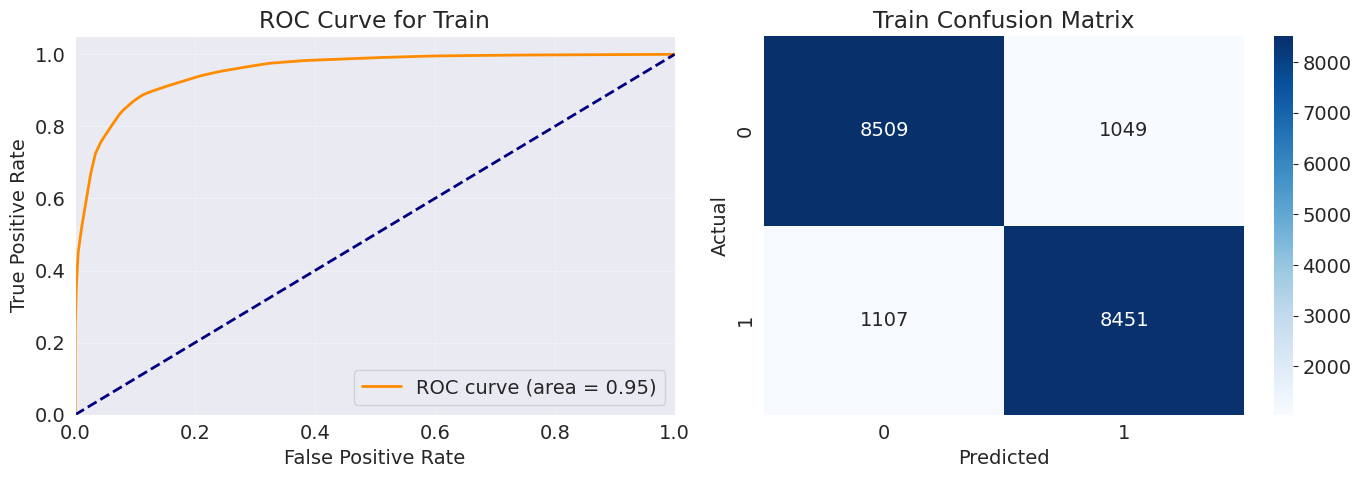

===== Train Results =====
    AUROC: 0.9543
    F1 Score: 0.8869
    




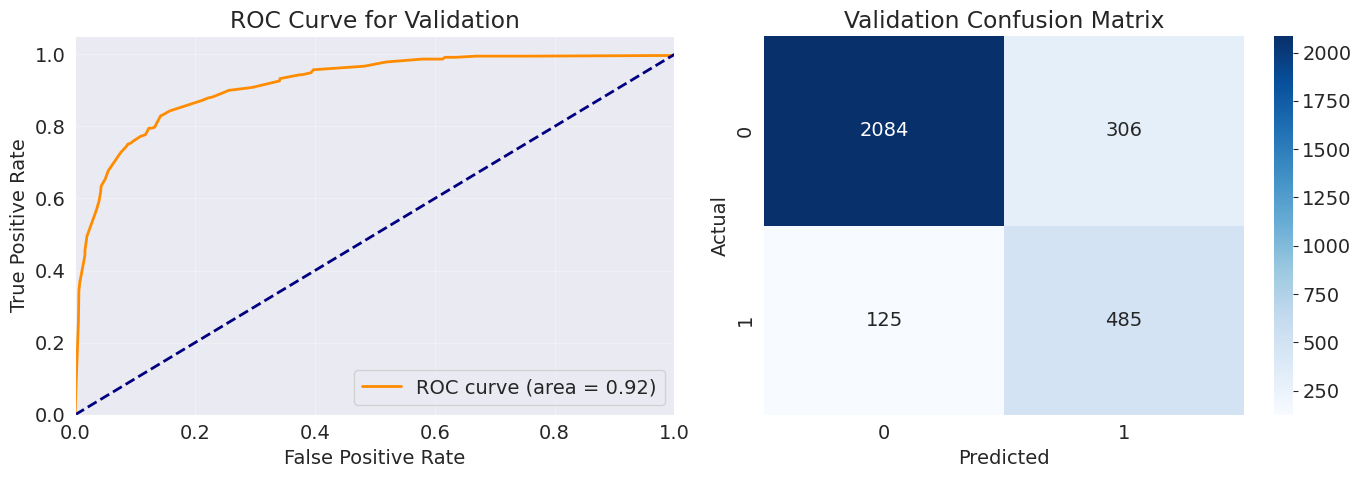

===== Validation Results =====
    AUROC: 0.9173
    F1 Score: 0.6924
    


********************************************************************************************************************************************************************************************************




{'MAX_DEPTH': 8}


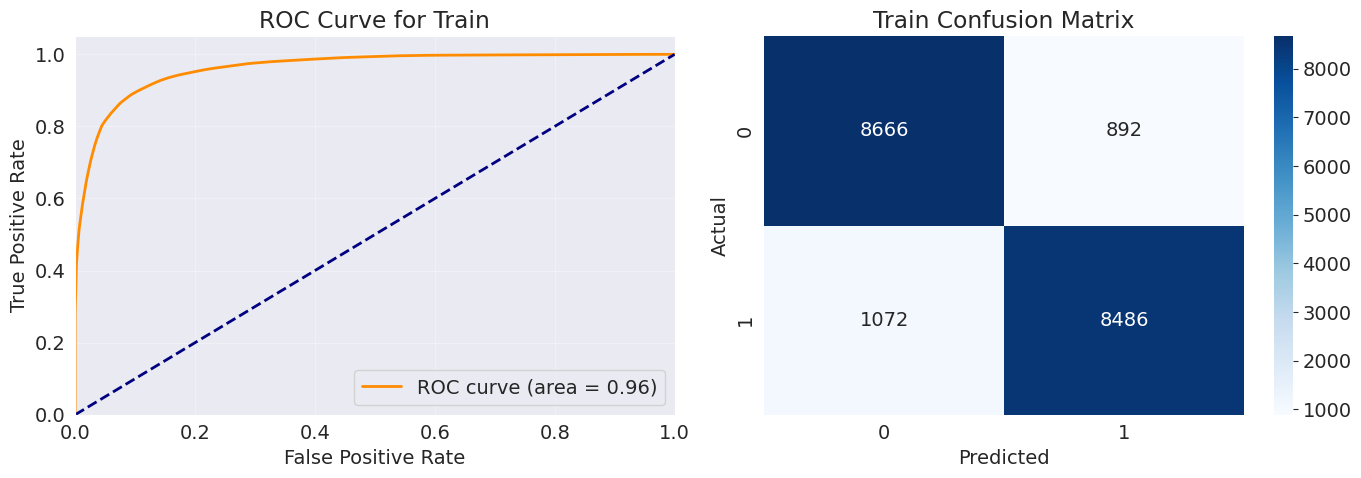

===== Train Results =====
    AUROC: 0.9622
    F1 Score: 0.8963
    




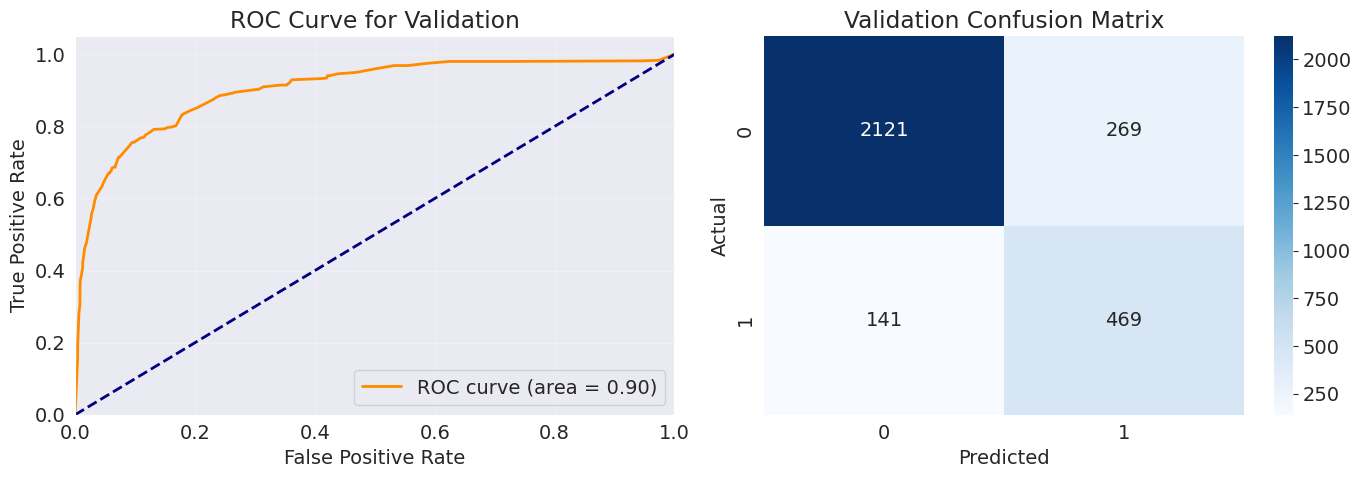

===== Validation Results =====
    AUROC: 0.9043
    F1 Score: 0.6958
    


********************************************************************************************************************************************************************************************************




{'MAX_DEPTH': 9}


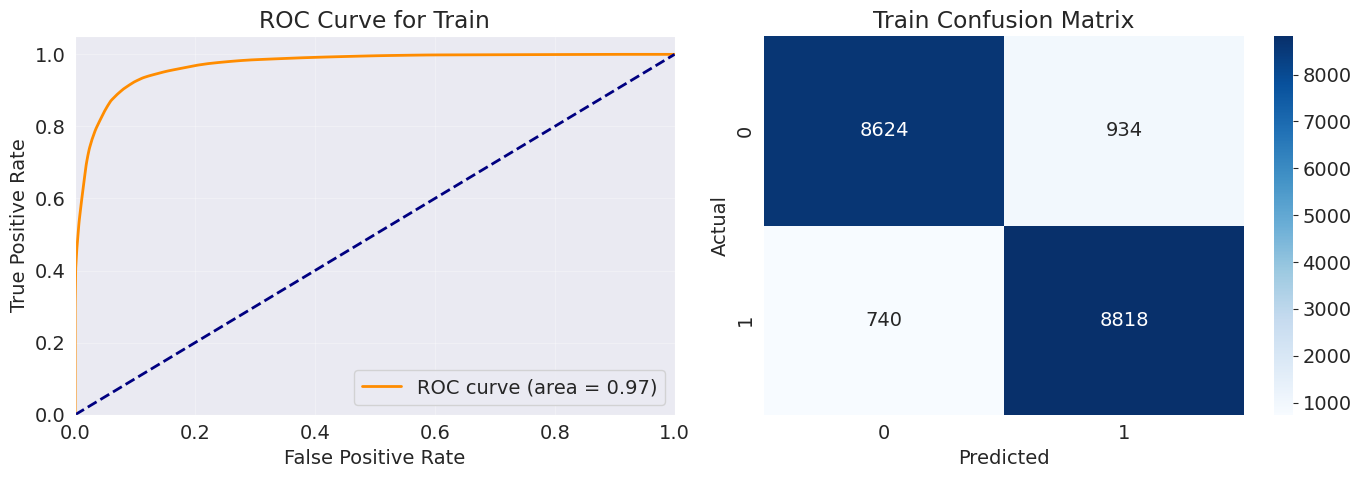

===== Train Results =====
    AUROC: 0.9704
    F1 Score: 0.9133
    




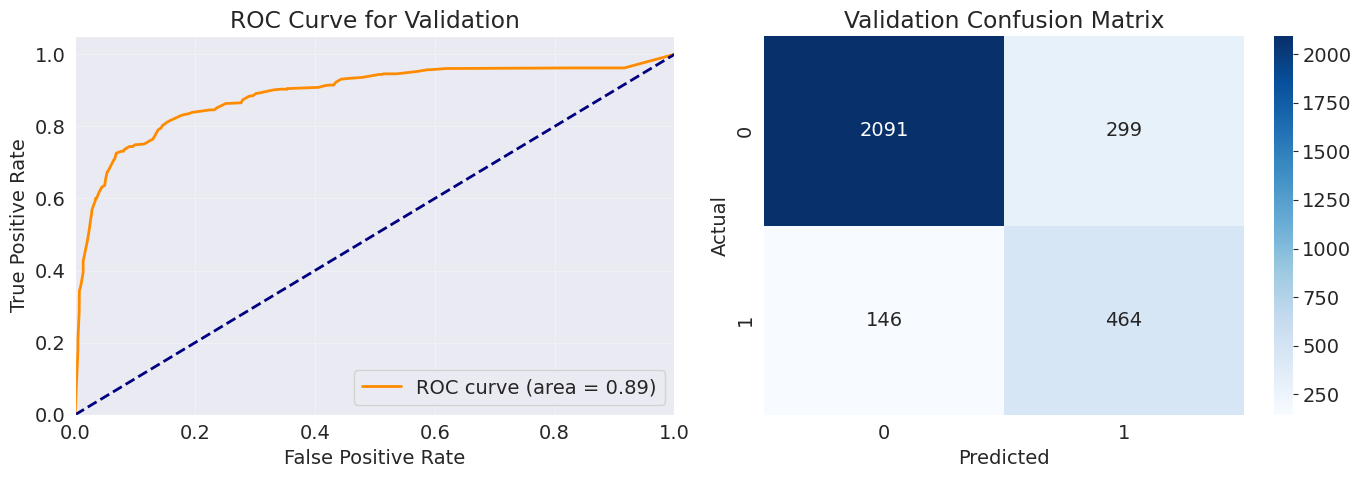

===== Validation Results =====
    AUROC: 0.8898
    F1 Score: 0.6759
    


********************************************************************************************************************************************************************************************************




{'MAX_DEPTH': 10}


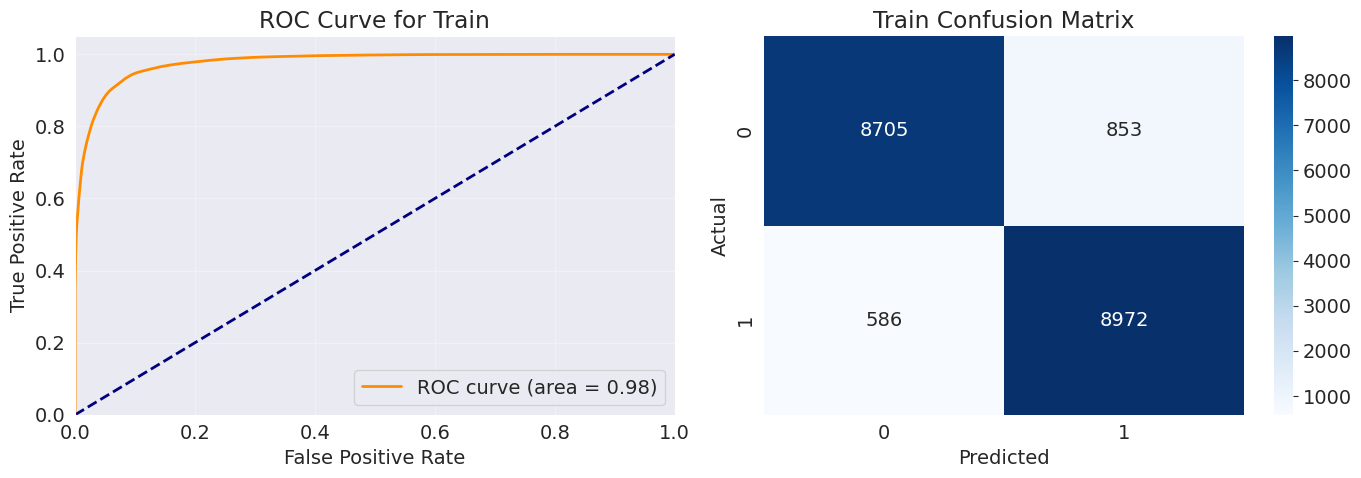

===== Train Results =====
    AUROC: 0.9781
    F1 Score: 0.9258
    




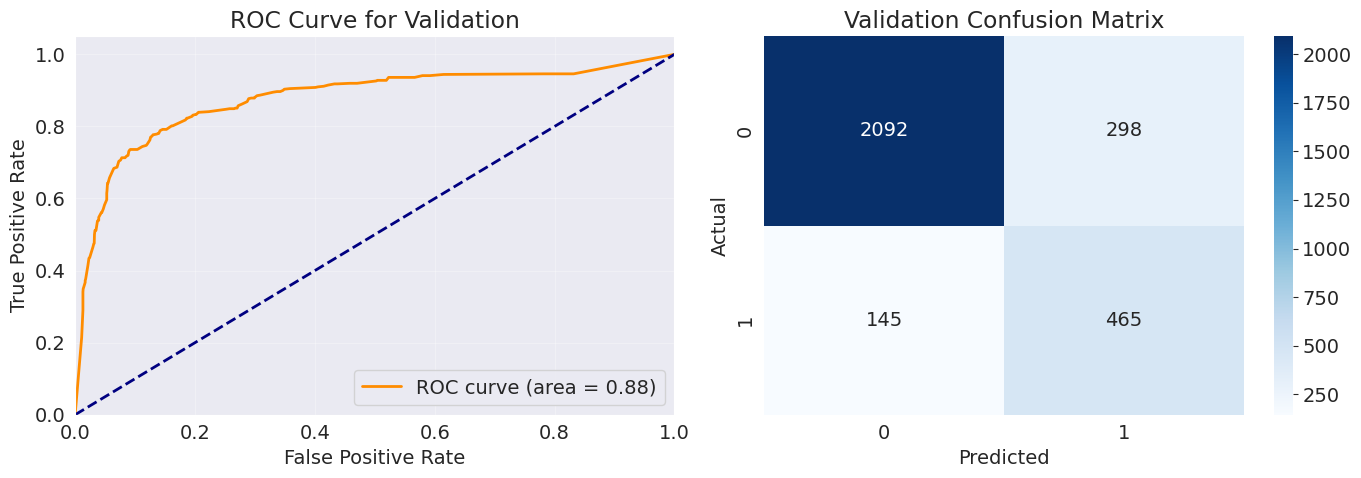

===== Validation Results =====
    AUROC: 0.8761
    F1 Score: 0.6773
    


********************************************************************************************************************************************************************************************************




{'MAX_DEPTH': 11}


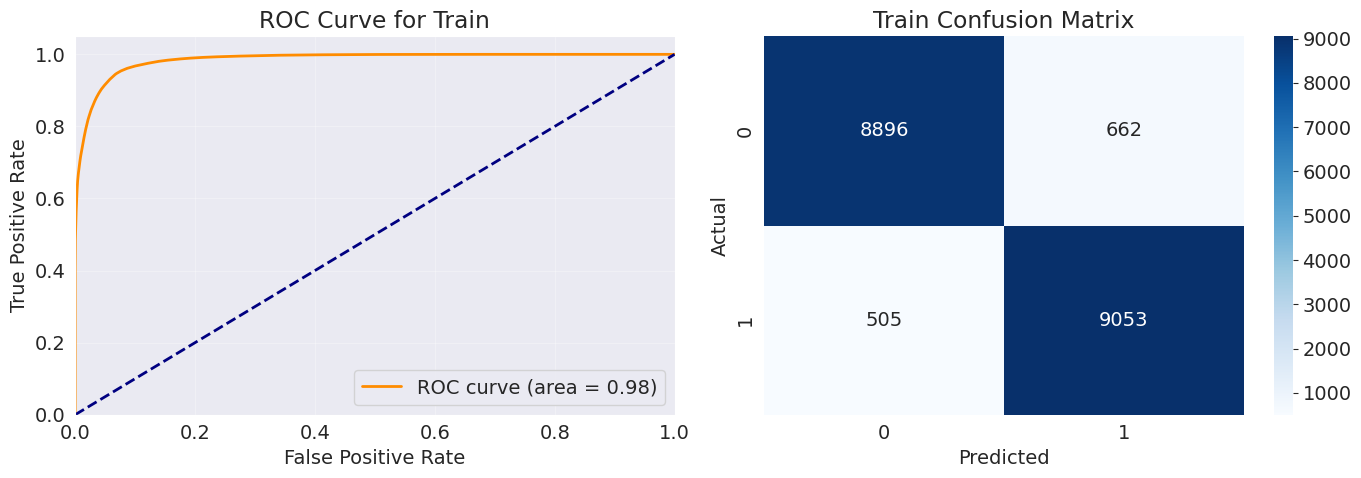

===== Train Results =====
    AUROC: 0.9849
    F1 Score: 0.9394
    




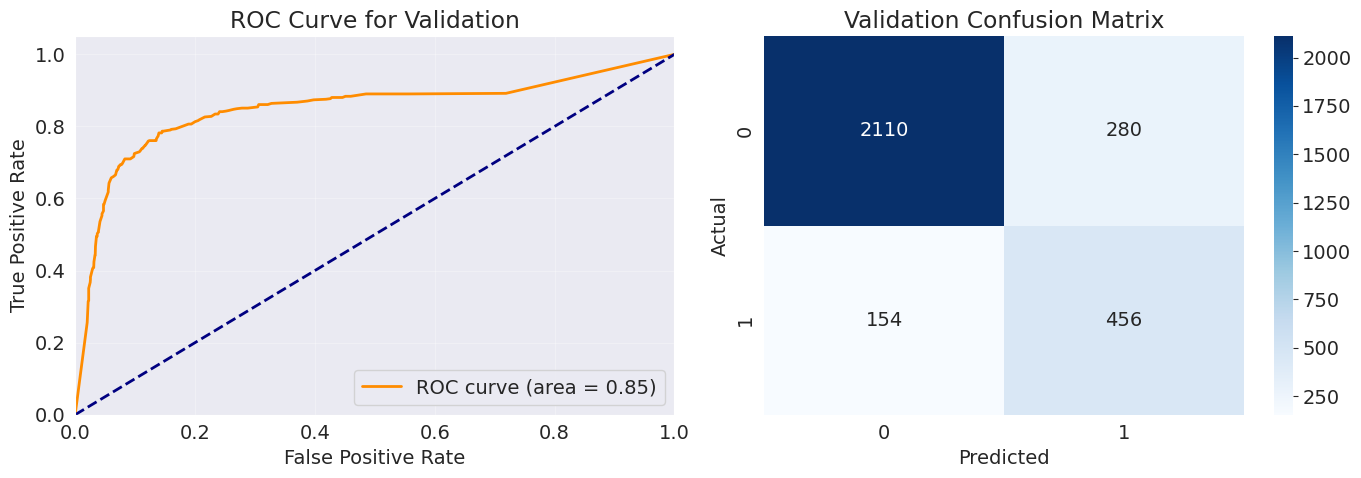

===== Validation Results =====
    AUROC: 0.8478
    F1 Score: 0.6776
    


********************************************************************************************************************************************************************************************************




{'MAX_DEPTH': 12}


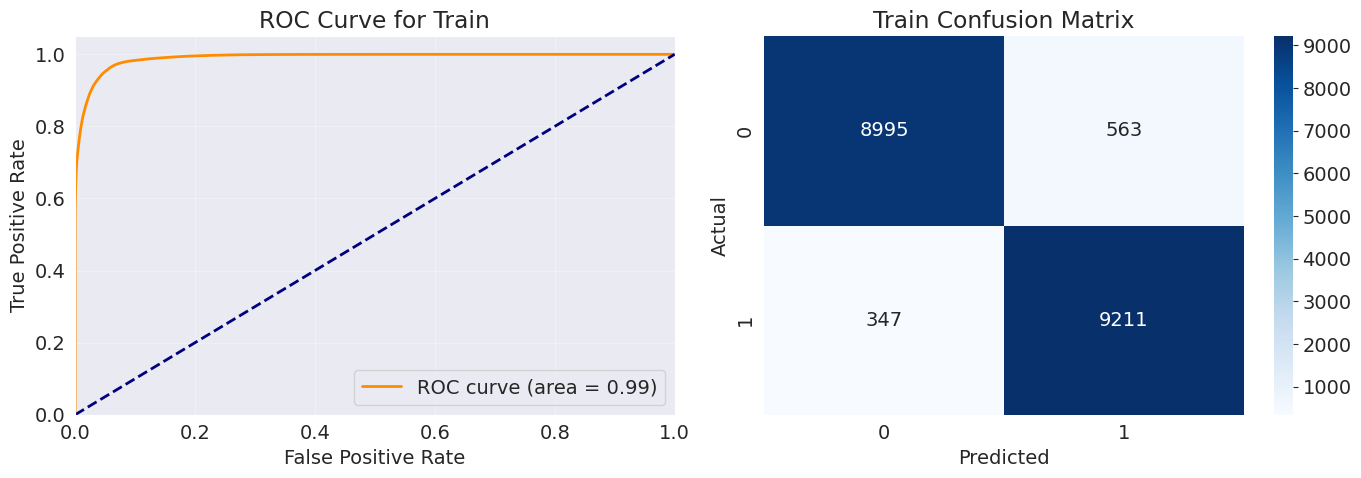

===== Train Results =====
    AUROC: 0.9907
    F1 Score: 0.9529
    




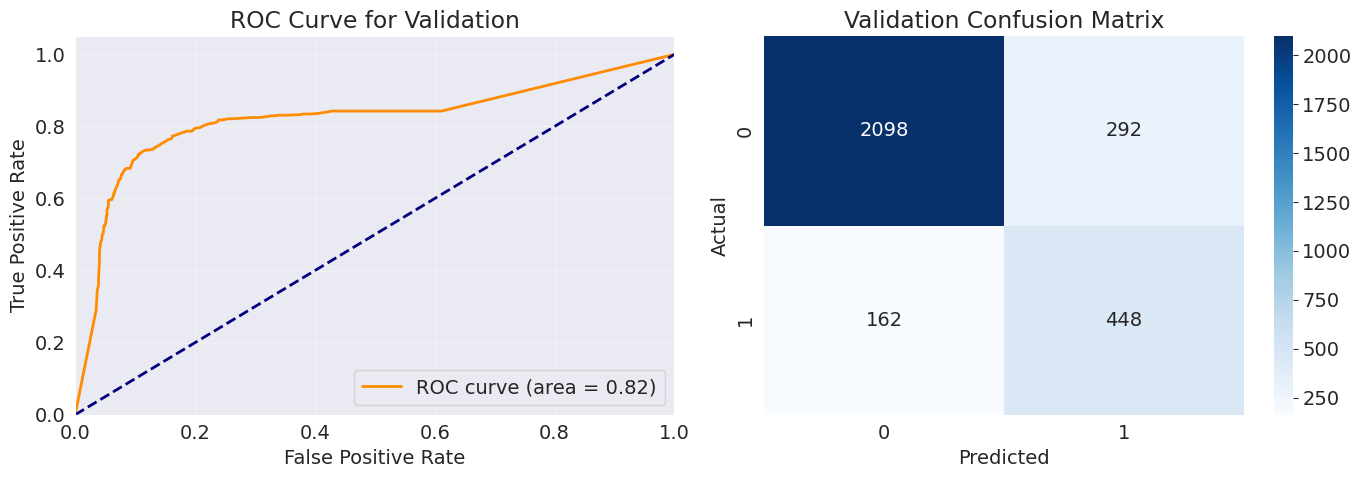

===== Validation Results =====
    AUROC: 0.8203
    F1 Score: 0.6637
    


********************************************************************************************************************************************************************************************************




{'MAX_DEPTH': 13}


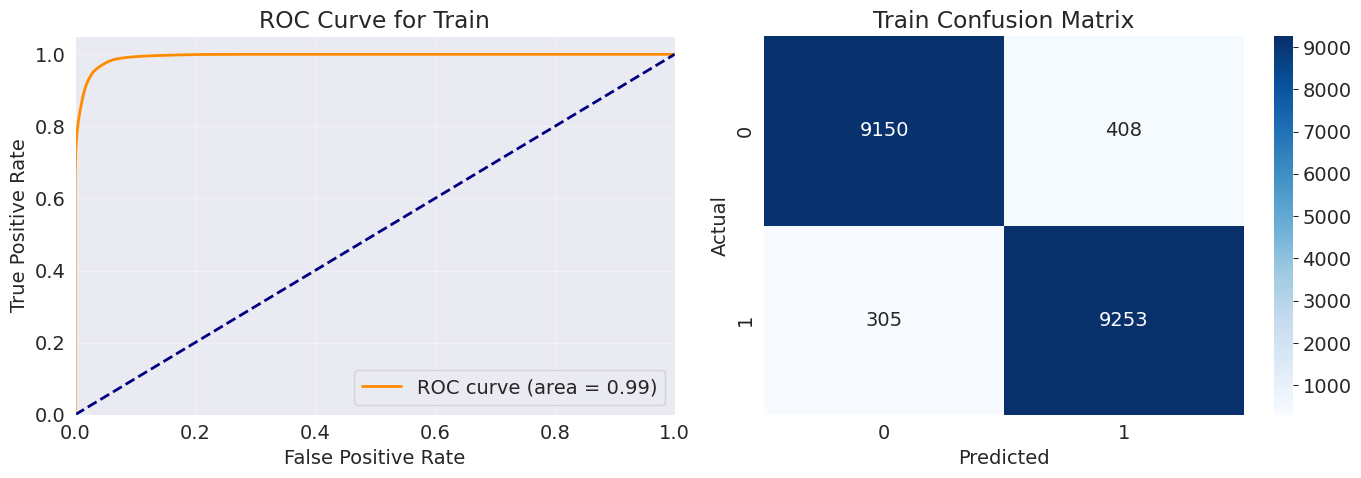

===== Train Results =====
    AUROC: 0.9946
    F1 Score: 0.9629
    




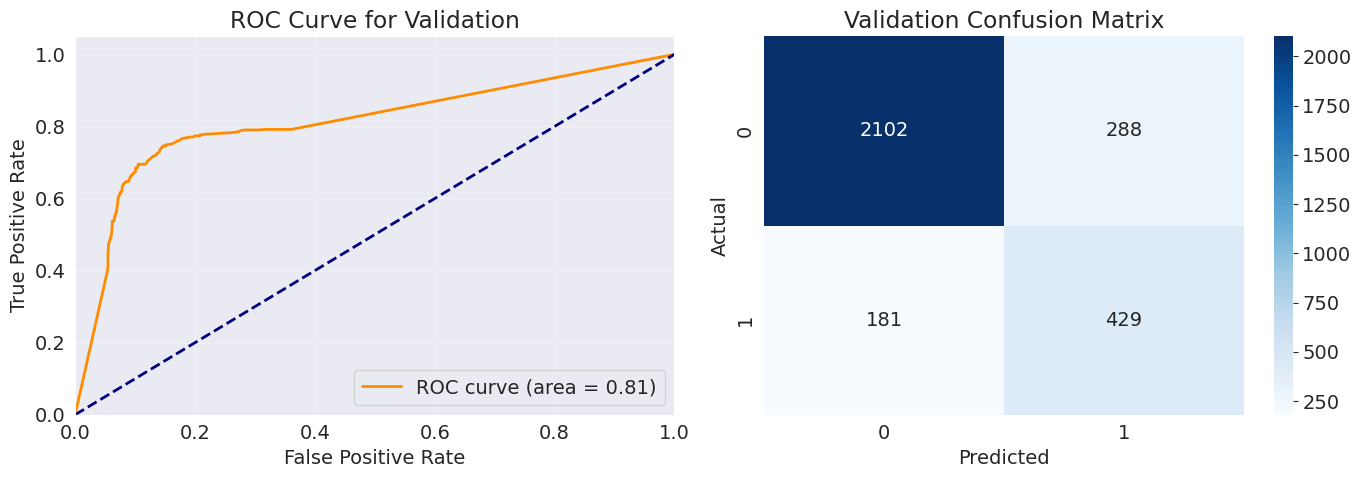

===== Validation Results =====
    AUROC: 0.8109
    F1 Score: 0.6466
    


********************************************************************************************************************************************************************************************************




{'MAX_DEPTH': 14}


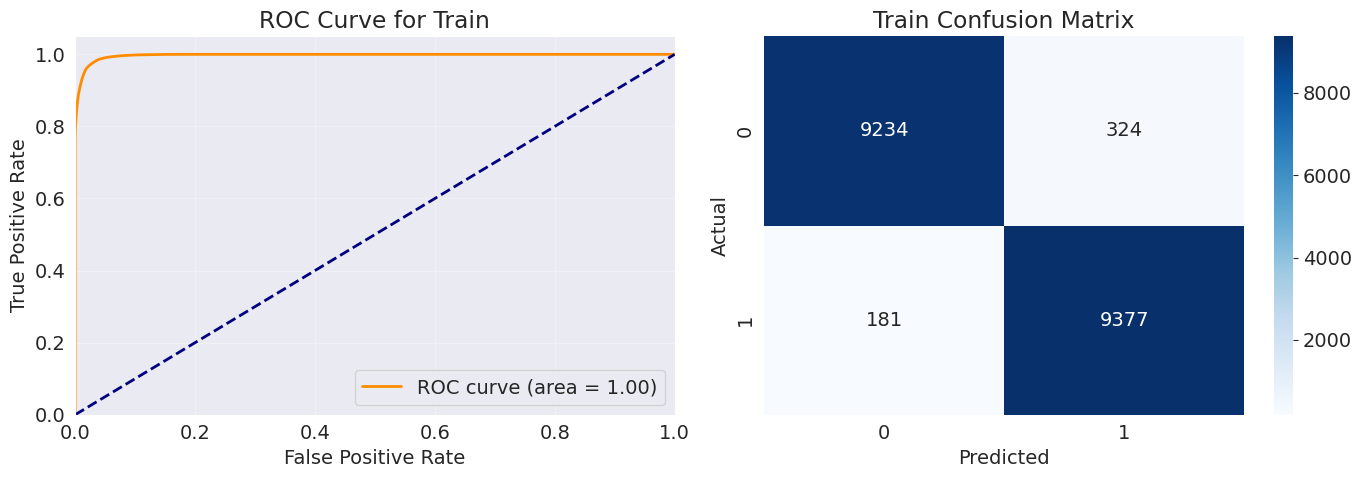

===== Train Results =====
    AUROC: 0.9973
    F1 Score: 0.9738
    




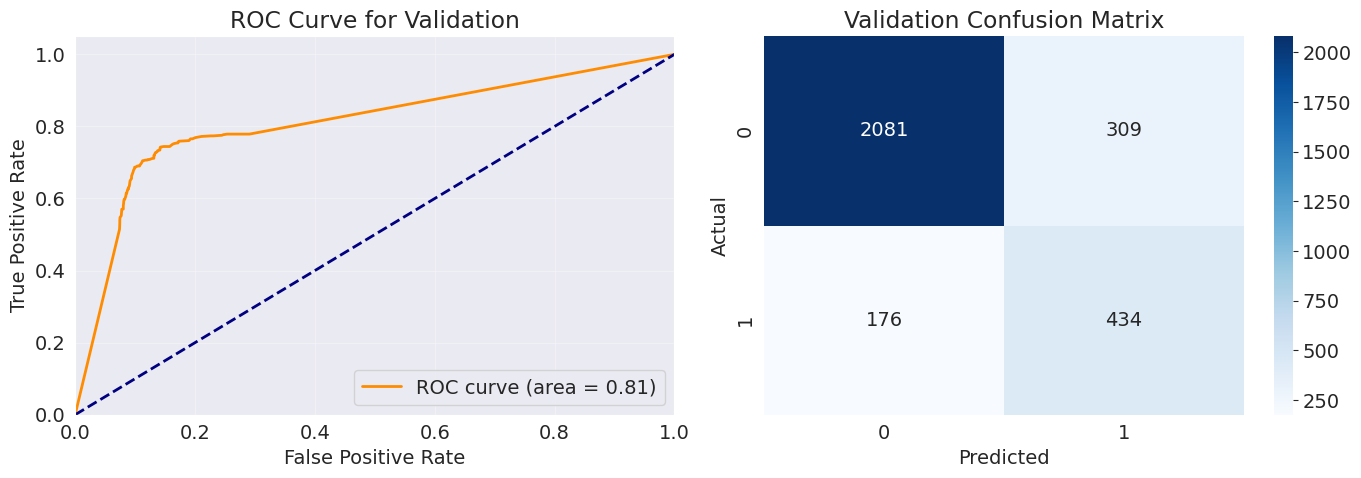

===== Validation Results =====
    AUROC: 0.8098
    F1 Score: 0.6415
    


********************************************************************************************************************************************************************************************************




{'MAX_DEPTH': 15}


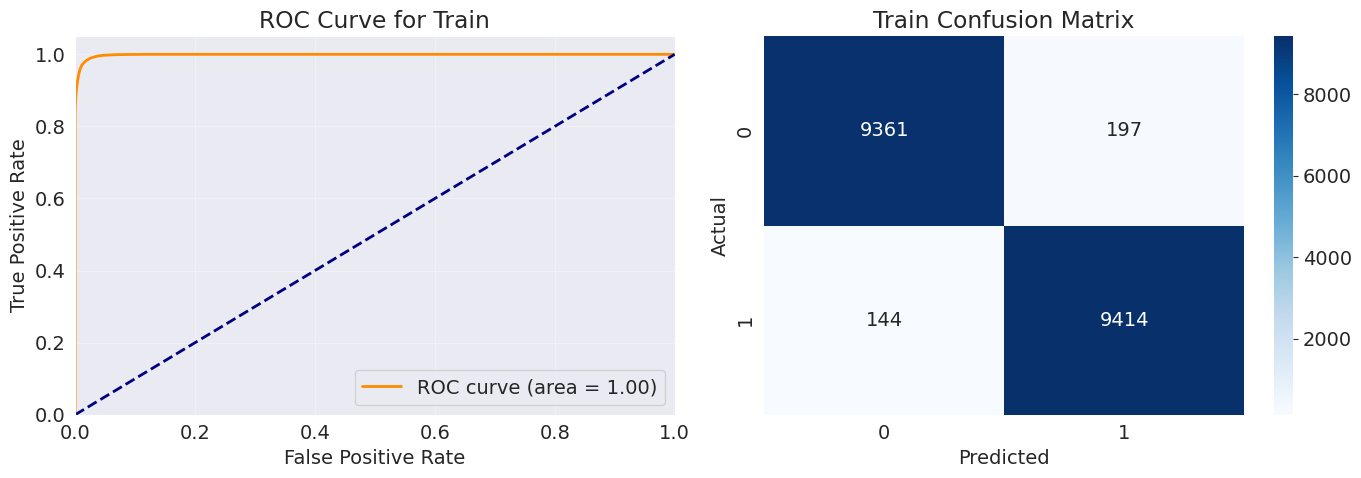

===== Train Results =====
    AUROC: 0.9988
    F1 Score: 0.9822
    




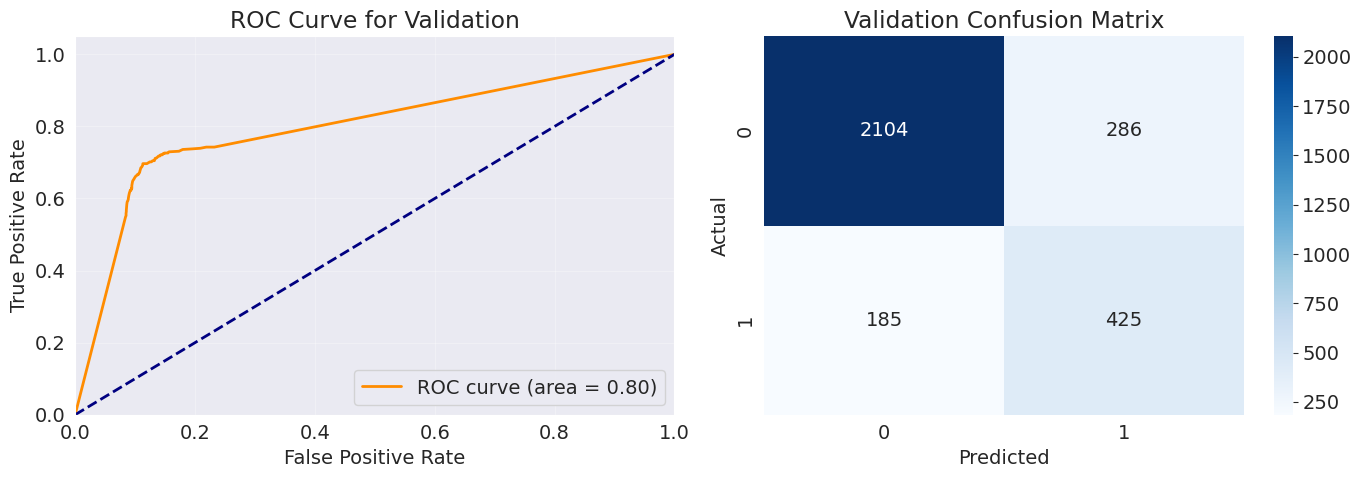

===== Validation Results =====
    AUROC: 0.7974
    F1 Score: 0.6435
    


********************************************************************************************************************************************************************************************************




{'MAX_DEPTH': 16}


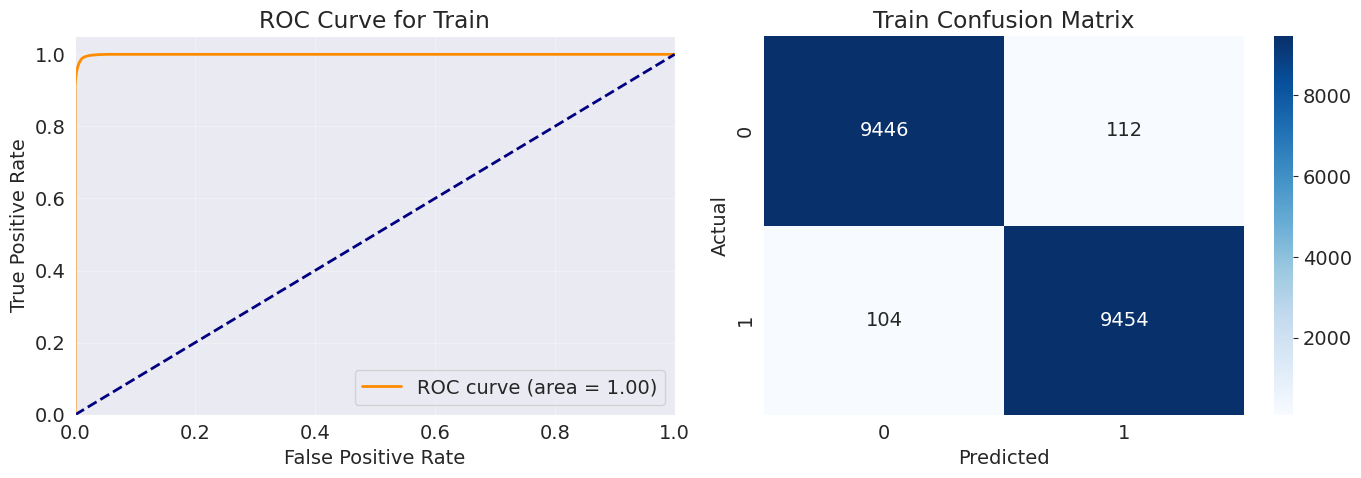

===== Train Results =====
    AUROC: 0.9995
    F1 Score: 0.9887
    




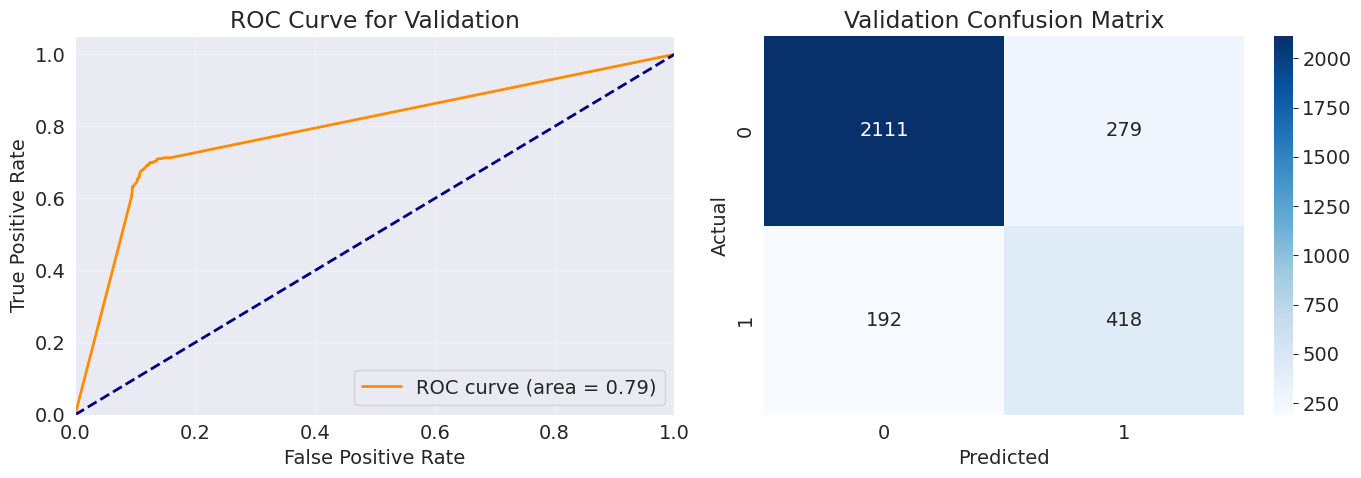

===== Validation Results =====
    AUROC: 0.7935
    F1 Score: 0.6396
    


********************************************************************************************************************************************************************************************************




{'MAX_DEPTH': 17}


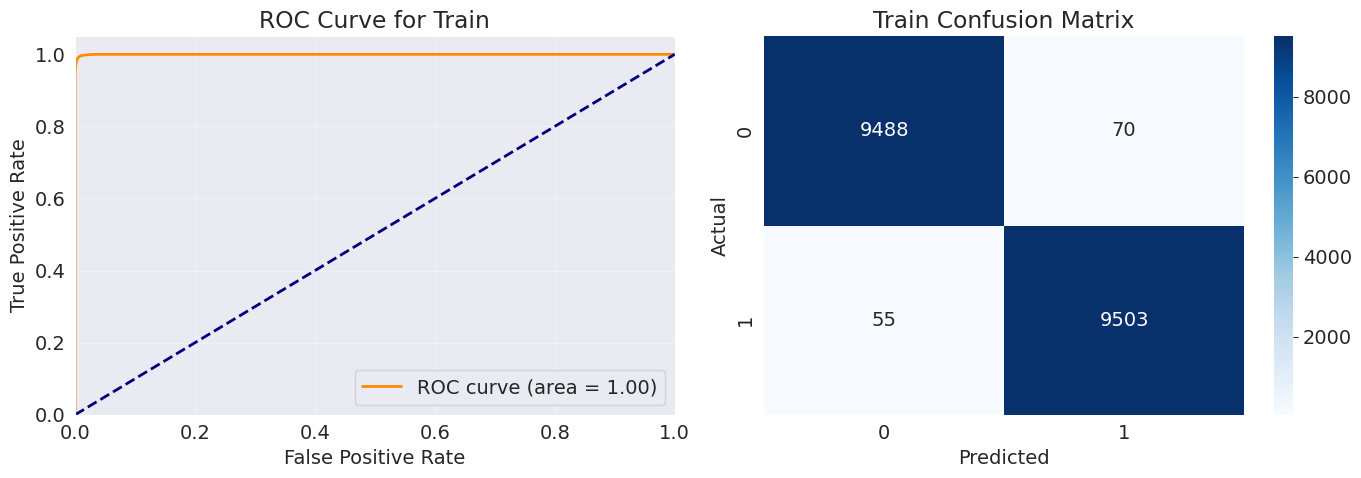

===== Train Results =====
    AUROC: 0.9998
    F1 Score: 0.9935
    




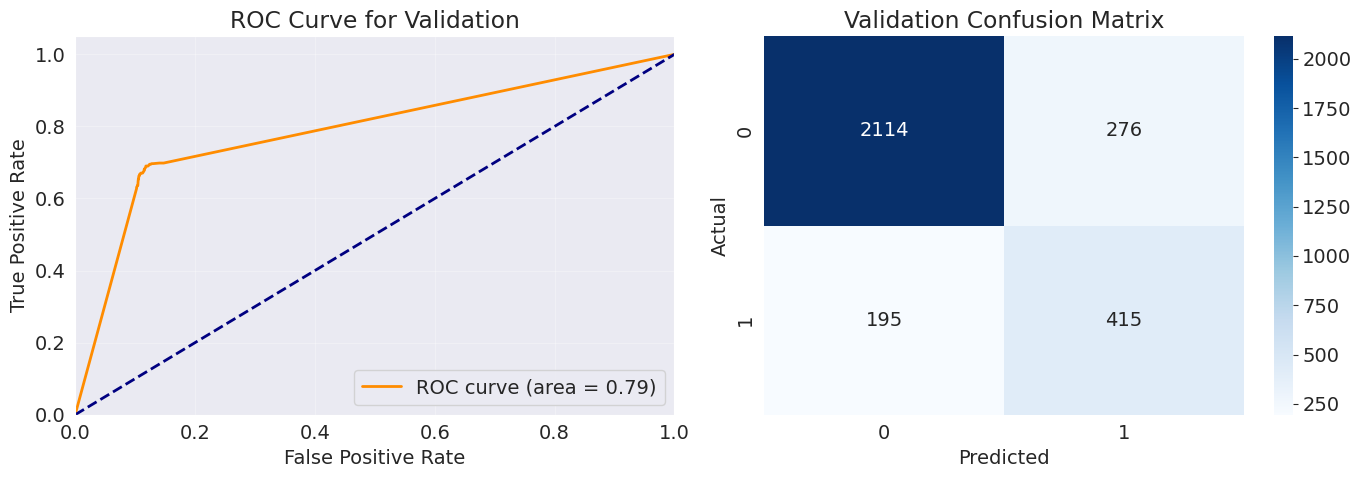

===== Validation Results =====
    AUROC: 0.7869
    F1 Score: 0.6380
    


********************************************************************************************************************************************************************************************************




{'MAX_DEPTH': 18}


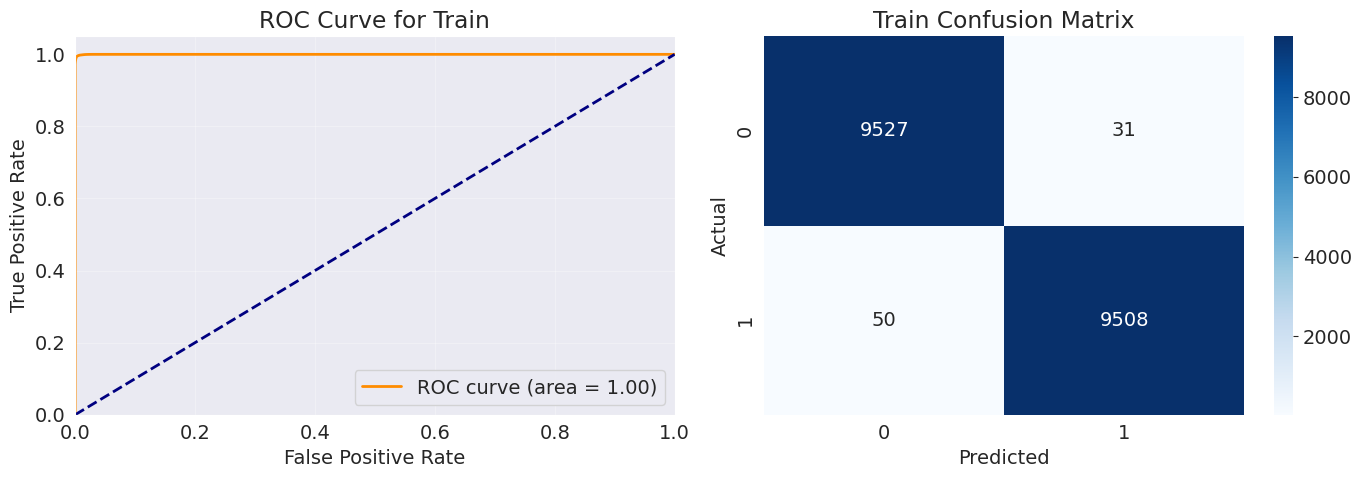

===== Train Results =====
    AUROC: 0.9999
    F1 Score: 0.9958
    




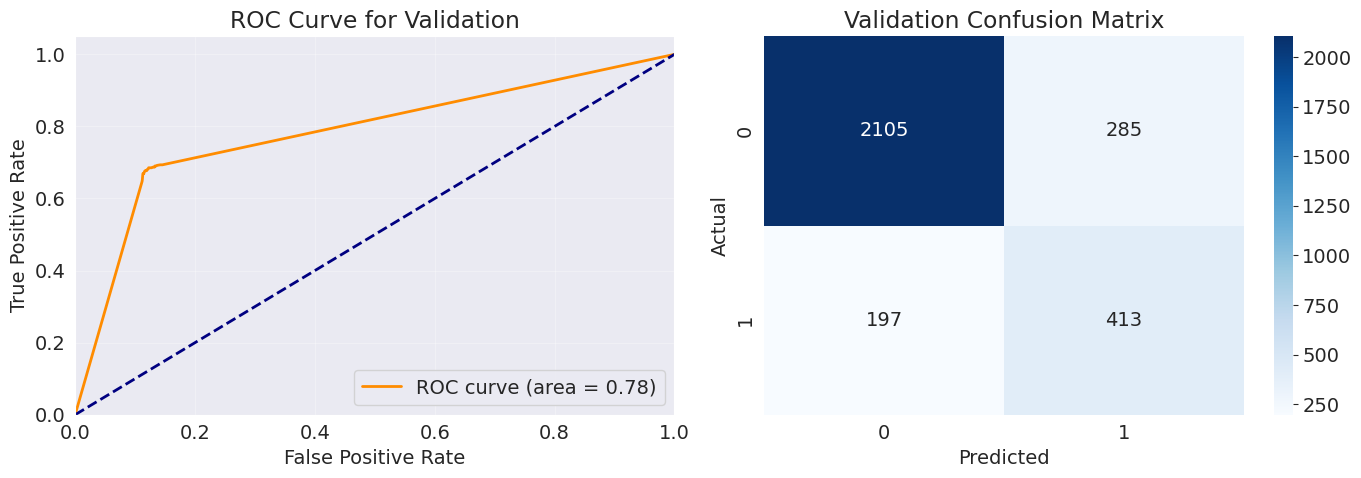

===== Validation Results =====
    AUROC: 0.7828
    F1 Score: 0.6315
    


********************************************************************************************************************************************************************************************************




{'MAX_DEPTH': 19}


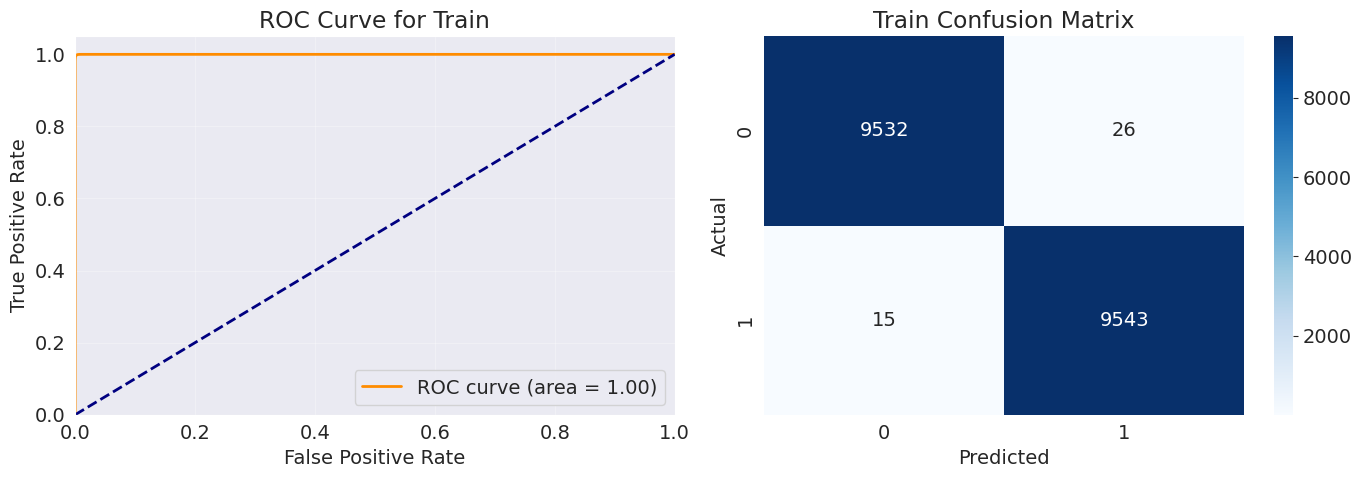

===== Train Results =====
    AUROC: 1.0000
    F1 Score: 0.9979
    




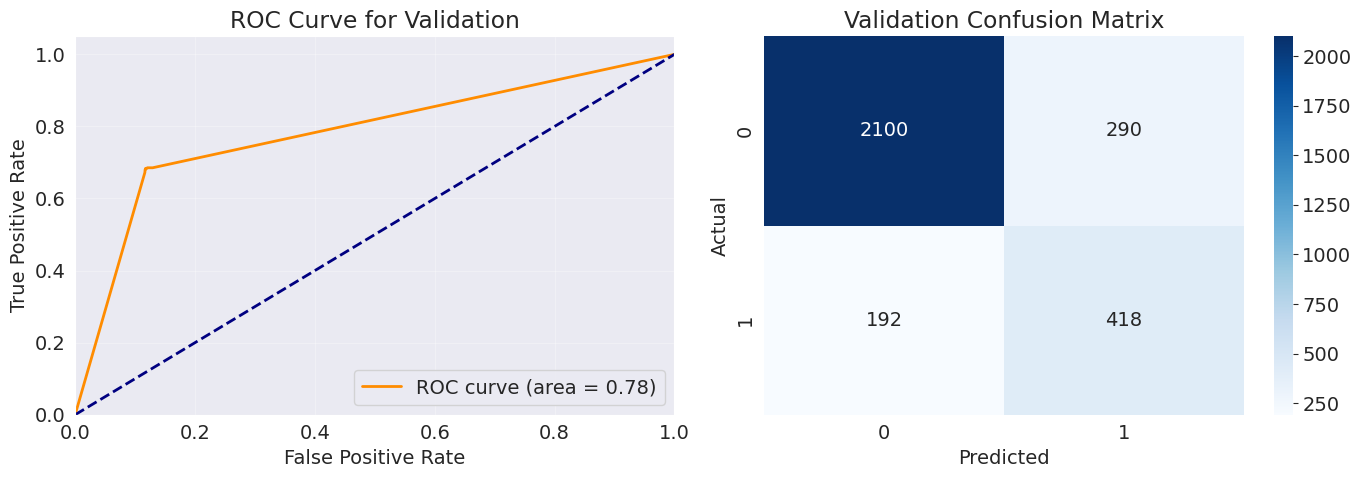

===== Validation Results =====
    AUROC: 0.7816
    F1 Score: 0.6343
    


********************************************************************************************************************************************************************************************************




{'MAX_DEPTH': 20}


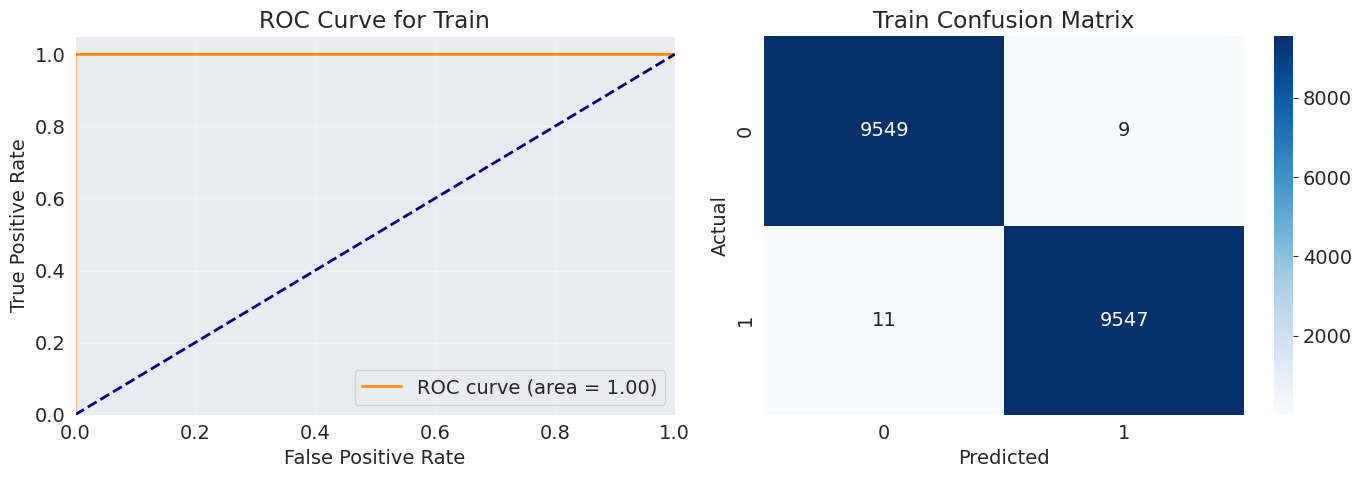

===== Train Results =====
    AUROC: 1.0000
    F1 Score: 0.9990
    




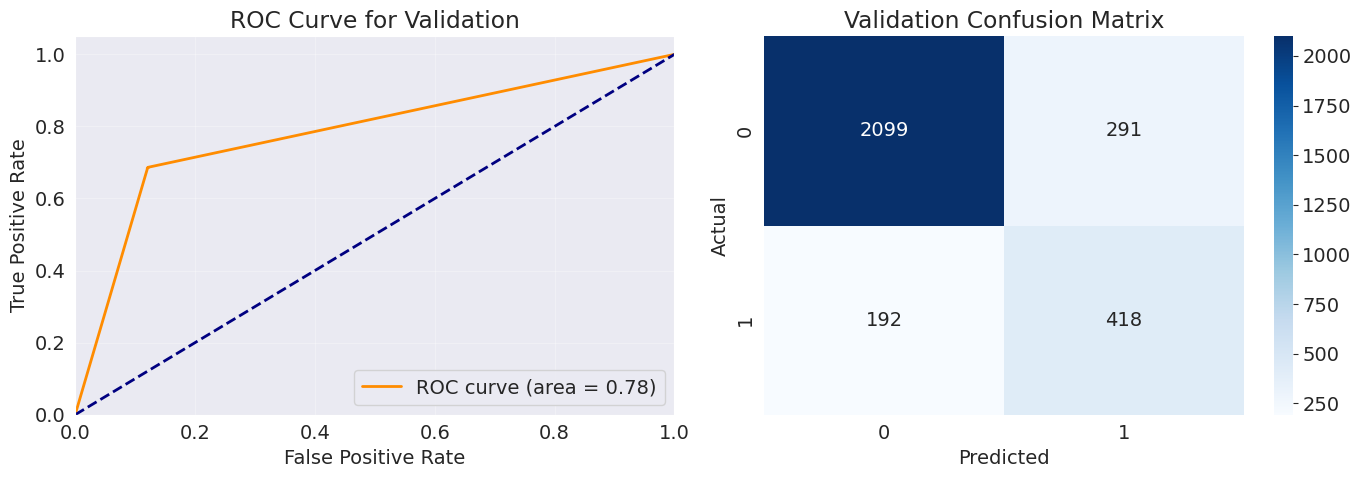

===== Validation Results =====
    AUROC: 0.7826
    F1 Score: 0.6338
    


********************************************************************************************************************************************************************************************************






In [36]:
experiments = [
    {"max_depth": d} for d in range(1,21)
]

experiments_results_set_2 = run_experiments(experiments)

In [37]:
results_set_2_df = pd.DataFrame(experiments_results_set_2).sort_values("val_auroc", ascending=False)
results_set_2_df.style.background_gradient(cmap="YlOrRd", subset=["train_auroc", "val_auroc"])

,max_depth,train_auroc,val_auroc
6,7,0.954253,0.917319
5,6,0.946513,0.916341
4,5,0.937390,0.914150
7,8,0.962219,0.904315
3,4,0.923434,0.902635
2,3,0.907407,0.890221
8,9,0.970361,0.889842
9,10,0.978123,0.876137
1,2,0.864555,0.849201
10,11,0.984941,0.847781


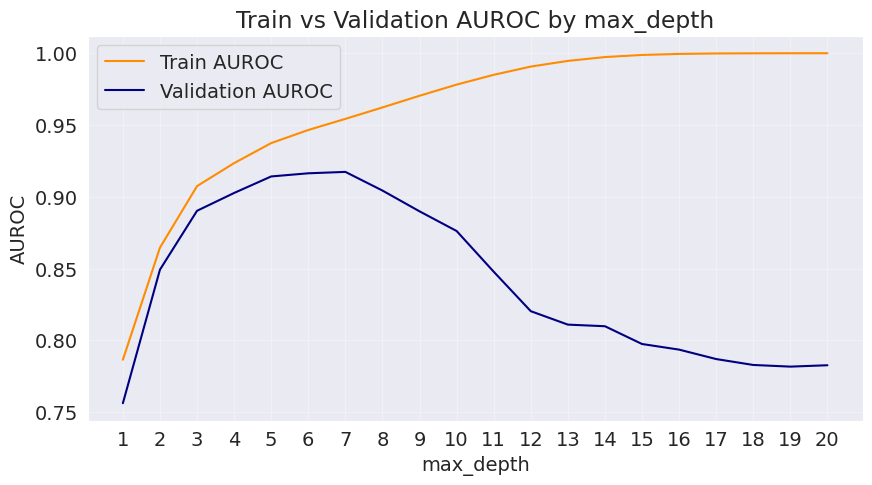

In [38]:
train_aucs = [r['train_auroc'] for r in experiments_results_set_2]
val_aucs = [r['val_auroc'] for r in experiments_results_set_2]

plt.figure(figsize=(10, 5))
plt.plot(range(1, 21), train_aucs, label="Train AUROC", color="darkorange")
plt.plot(range(1, 21), val_aucs, label="Validation AUROC", color="navy")
plt.xlabel("max_depth")
plt.ylabel("AUROC")
plt.title("Train vs Validation AUROC by max_depth")
plt.xticks(range(1, 21))
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## **Завдання 5**.
1. Натренуйте модель `DecisionTree` з найкращим значенням `max_depth`, яке ви знайшли на попередній ітерації.
2. Завантажте тестові дані змагання з `test.csv`.
3. Зробіть попередню обробку даних з функцією `preprocess_new_data` з вашого модуля `process_bank_churn.py`.
4. Зробіть передбачення використовуючи цю модель на тестових даних змагання.
5. Сформуйте `submission.csv`.
6. Зробіть новий Submission на Kaggle і додайте тут скріншот Вашого скору на паблік лідерборді :)


max_depth          8.000000
max_leaf_nodes    39.000000
train_auroc        0.942876
val_auroc          0.922837
Name: 7, dtype: float64




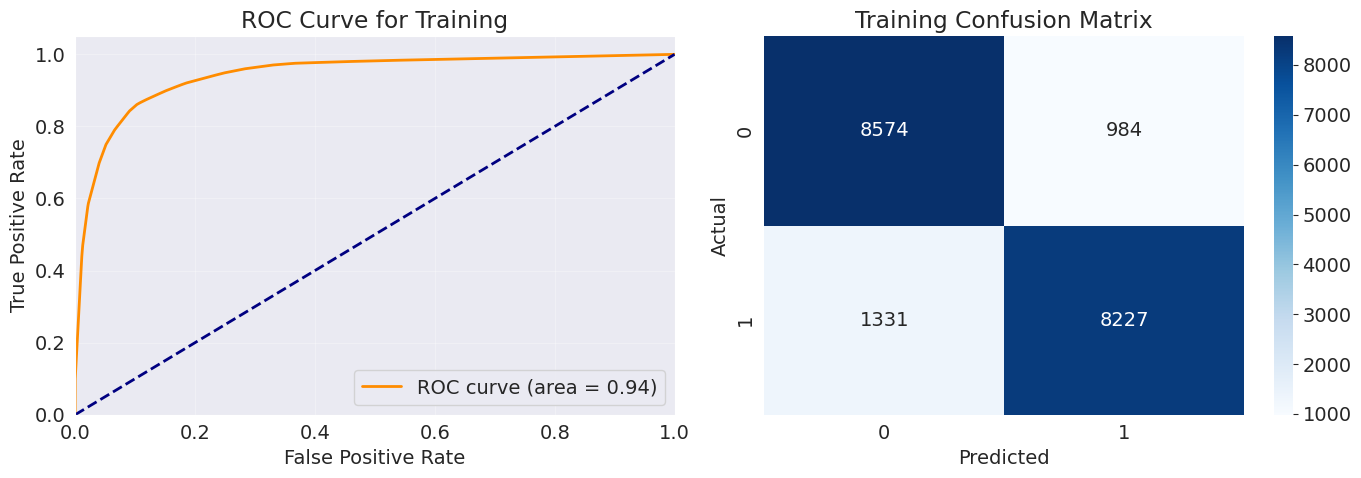

===== Training Results =====
    AUROC: 0.9429
    F1 Score: 0.8767
    




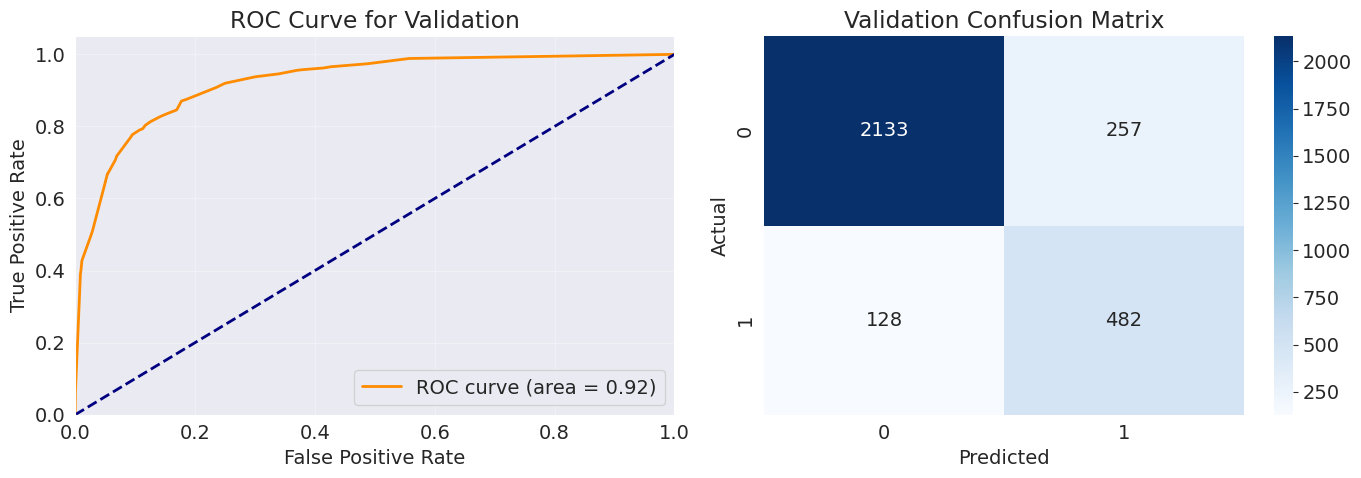

===== Validation Results =====
    AUROC: 0.9228
    F1 Score: 0.7146
    




(array([1., 0., 0., ..., 0., 0., 0.]), np.float64(0.922837300226353))

In [39]:
best = results_set_1_df.iloc[0]
print(best, end='\n\n\n')

best_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=int(best["max_depth"]),
    max_leaf_nodes=int(best["max_leaf_nodes"]),
)
best_model.fit(X_train, train_targets)

predict_and_plot(best_model, X_train, train_targets, "Training")
predict_and_plot(best_model, X_val, val_targets, "Validation")

In [40]:
# Я спробувала Prunning, але чомусь він особливо нічого не покращив для best model
# потім видалила, але все одно цікаво чому

In [41]:
X_test = preprocess_new_data(
    new_df=raw_test_df,
    input_cols=input_cols,
    scaler=scaler,
    encoder=encoder
    )
test_preds = best_model.predict_proba(X_test)[:, 1]

submission = raw_sample_submission.copy()
submission["Exited"] = test_preds

submission.to_csv("submission_decision_tree.csv", index=False)
submission.head()

,id,Exited
0,15000,0.295918
1,15001,0.034284
2,15002,0.182815
3,15003,0.818499
4,15004,0.182815
